# Project Han

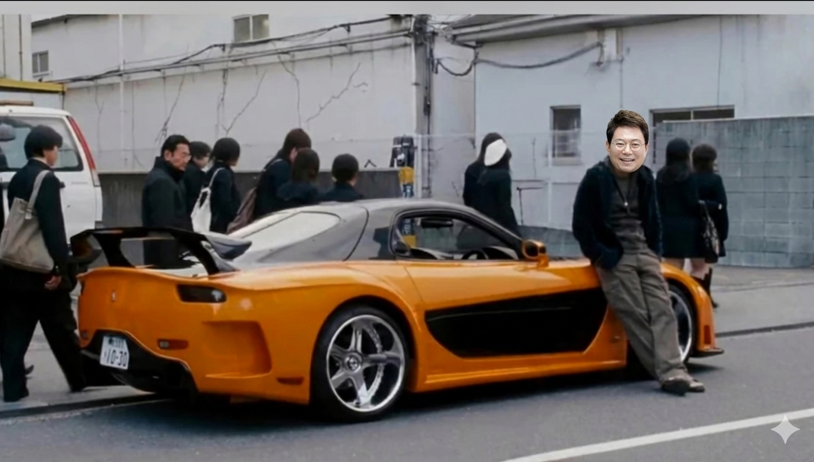

# 프로젝트 Han

### -개요
#### 사후 처리를 위험도 분석을 통해서 운전자가 사고 또는 회피 후에 당시 상황이 얼마나 위험했나 평가하기 위한 프로그램.

야간 바이크 POV 영상에 U-Net 기반 segmentation, YOLO 기반 객체 탐지, 기하학 기반 거리 계산을 통합해서  
사진 한 장마다 0~100% 의 Risk Score 를 산출하는 시스템.

---

## 목차

### 1. EDA (탐색적 데이터 분석)
- 이미지 폴더 / JSON annotation 매칭 확인
- 두 파일 그룹 (Screenshot / night ride) 패턴 분석
- 해상도 확인 (1920x1080 단일 해상도)
- 클래스별 통계: Moveable 1298개, Lane Mark 1.4%, Undrivable 42.9%
- 가설 검증용 Lane Mark 개수 분포 확인

### 2. 마스크 시각화 및 라벨 생성
- pycocotools 로 annotation 로드
- 클래스별 색상 매핑
- 클래스 ID 재매핑 (COCO id → 0~6)
- 라벨 마스크 생성 함수

### 3. 데이터셋 / 데이터로더 구성
- PyTorch Dataset 클래스 구현
- train 160 / val 40 split (8:2)
- 데이터로더 제작 (배치 8)

### 4. U-Net 모델 구현
- DoubleConv 블록 + Encoder 4단계 + Bottleneck + Decoder 4단계
- Skip Connection 으로 위치 정보 보존
- 총 파라미터 약 3,100만

### 5. 손실 함수 / 평가 지표
- CrossEntropyLoss 정의
- IoU 메트릭 함수 구현 (클래스별 IoU 측정)

### 6. 베이스라인 학습 (실험 1)
- Adam optimizer, lr 1e-4, 30 epoch
- train mIoU 0.7007 → val mIoU 0.5186, Lane Mark 0.0681
- 학습 곡선 / 예측 결과 시각화

### 7. 개선 실험 (실험 2) - Weighted CrossEntropy
- Lane Mark 클래스에 가중치 8배 적용
- Lane Mark val IoU 0.0681 → 0.3775 (+30.93%p)
- 전체 val mIoU 0.5186 → 0.6102 (+9.16%p)
- Moveable 도 0.2845 → 0.4378 (+15.32%p) 덤으로 개선됨

### 8. YOLO 통합 (거리 계산 기능)
- YOLO11n 사전학습 모델 사용
- Moveable sub-class 분류 (Truck/Car/Bus/Motorcycle/Bicycle/Human)
- My bike 상단 중앙 = 라이더 시점 좌표
- forward_dist 계산 (y축 기반 앞뒤 거리)
- My bike 자체 오인식 필터링 (motorcycle 클래스만 적용)

### 9. Risk Score 공식 통합
- 팀 제공 클래스별 위험도 가중치 딕셔너리 반영
- Moveable: instance 별로 (가중치 × 면적비율 × 거리가중치) 합산
- Undrivable: 면적비율 × 평균 가중치 0.138 (sub-class 라벨 없으므로 fallback)
- Road / Lane Mark: 가중치 0 으로 공식에서 제외 (팀 결정)
- 선형 매핑 + clip 으로 0~1 정규화

### 10. 테스트 데이터 적용 및 튜닝
- 팀 제공 test 327장 (5개 영상 스크린샷)
- 전체 파이프라인 일괄 처리
- 파라미터 튜닝: distance_threshold 800 → 400, moveable_scale 30 → 20
- rs = 1.0 이 21장 → 5장 으로 감소 (과도 위험 문제 해결)
- 5단계 구간별 분포: Safe 250장 / Mostly Safe 49장 / Moderate 16장 / Warning 4장 / Danger 8장

### 11. 결과 시각화 및 시연
- 5단계 히트맵 색상 매핑 (SAFE / MOSTLY SAFE / MODERATE / WARNING / DANGER)
- 단일 이미지 리포트 (원본 / 분석 / 위험도 텍스트)
- 5단계 구간별 샘플 5장씩 그리드
- 실시간 이미지 분석 함수 (analyze_new_image)
- 영상 처리 기능 (프레임 샘플링 + rs smoothing)

---

## 핵심 실험 결과 요약

| 실험 | val mIoU | Lane Mark val IoU |
|---|---|---|
| Baseline (CrossEntropyLoss) | 0.5186 | 0.0681 |
| Weighted CE (Lane Mark ×8) | 0.6102 (+9.16%p) | 0.3775 (+30.93%p) |

가장 약했던 Lane Mark 클래스에서 30%p 이상의 드라마틱한 개선.  
덤으로 Moveable도 같이 향상되면서 전체 mIoU도 9%p 상승.

## 최종 Risk Score 공식

```
rs_raw = Σ (moveable 기여) × scale + (undrivable 기여) + bias
rs = clip((rs_raw + offset) / range, 0, 1)

moveable 기여 = 위험도 × bbox면적비율 × 거리가중치
거리가중치 = max(0, 1 - forward_dist / 400)
```

---

## 담당 역할

**초기 모델 작성 / 데이터 학습 / 성능 테스트**

U-Net 모델 구현부터 학습, Weighted CE 개선 실험,  
YOLO 통합, 거리 계산 로직, Risk Score 공식 및 튜닝,  
테스트 데이터 파이프라인, 시각화까지 담당.

In [1]:
# 프로젝트 Han - EDA 시작

import os
import json
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
from collections import Counter, defaultdict

# 경로 상수 (가이드 구조 그대로 유지함. 이름 절대 바꾸지 않음)
BASE_DIR = os.path.expanduser('~/work/motorcycle')
DATA_DIR = os.path.join(BASE_DIR, 'www.acmeai.tech ODataset 1 - Motorcycle Night Ride Dataset')
IMAGE_DIR = os.path.join(DATA_DIR, 'images')
ANNOTATION_FILE = os.path.join(DATA_DIR, 'COCO_motorcycle (pixel).json')

# 경로 위치 확인
print('BASE_DIR 확인 :', os.path.exists(BASE_DIR))
print('DATA_DIR 확인 :', os.path.exists(DATA_DIR))
print('IMAGE_DIR 확인:', os.path.exists(IMAGE_DIR))
print('ANNOTATION 확인:', os.path.exists(ANNOTATION_FILE))

BASE_DIR 확인 : True
DATA_DIR 확인 : True
IMAGE_DIR 확인: True
ANNOTATION 확인: True


#### 이미지 폴더 데이터 확인

In [2]:
img_files = sorted(os.listdir(IMAGE_DIR))
print(f'총 파일 수: {len(img_files)}개')
print(f'앞 3개 파일명: {img_files[:3]}')
print(f'뒤 3개 파일명: {img_files[-3:]}')

총 파일 수: 600개
앞 3개 파일명: ['Screenshot (309).png', 'Screenshot (309).png___fuse.png', 'Screenshot (309).png___save.png']
뒤 3개 파일명: ['night ride (99).png', 'night ride (99).png___fuse.png', 'night ride (99).png___save.png']


#### 랜덤하게 5개 확인

[0, 149, 299, 449, 599]


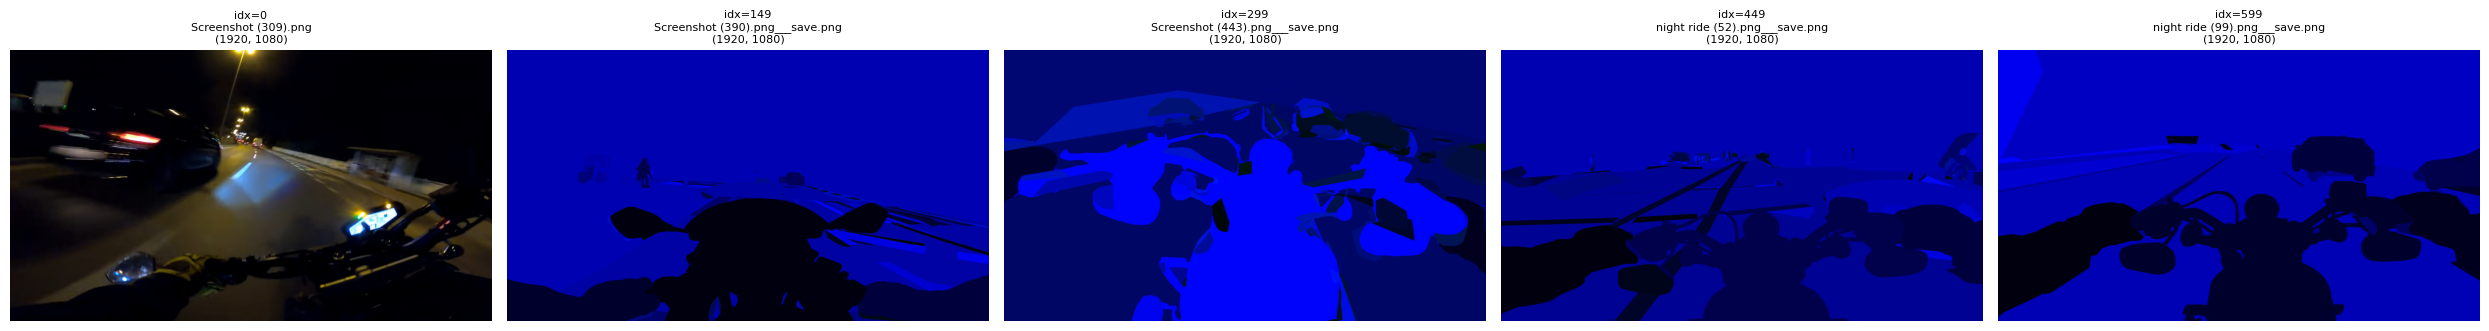

In [3]:
# 첫번째 이미지, 1/4, 중간, 3/4, 끝 이미지)
sample_idx = np.linspace(0, len(img_files)-1, 5, dtype=int)
print(sample_idx.tolist())

fig, axes = plt.subplots(1, 5, figsize=(25, 5))
for ax, idx in zip(axes, sample_idx):
    fname = img_files[idx]
    img_path = os.path.join(IMAGE_DIR, fname)
    img = Image.open(img_path)
    ax.imshow(img)
    # 제목에 파일명이랑 해상도도 표시 (이미지 크기 파악하려고)
    ax.set_title(f'idx={idx}\n{fname}\n{img.size}', fontsize=8)
    ax.axis('off')
plt.tight_layout()
plt.show()

### 대제목이 다른 파일들 각 몇장인지 확인

In [4]:
import re

# 원본 파일만 (fuse/save 제외)
originals = [f for f in img_files if '___' not in f]

# 패턴별 분류
pat_screenshot = [f for f in originals if f.lower().startswith('screenshot')]
pat_nightride = [f for f in originals if f.lower().startswith('night')]
pat_other = [f for f in originals if f not in pat_screenshot and f not in pat_nightride]

print(f'제목 (Screenshot) : {len(pat_screenshot)}개')
print(f'제목 (night 시작) : {len(pat_nightride)}개')
print(f'삔또확인 : {len(pat_other)}개')
print(f'합계 : {len(pat_screenshot) + len(pat_nightride) + len(pat_other)}개')
print(f'원본 전체 : {len(originals)}개')

print('\n패턴_1')
for f in pat_screenshot[:5]: print(f'  {f}')
print('\n패턴_2')
for f in pat_nightride[:5]: print(f'  {f}')
if pat_other:
    print('\n삔또')
    for f in pat_other[:5]: print(f'  {f}')

제목 (Screenshot) : 107개
제목 (night 시작) : 93개
삔또확인 : 0개
합계 : 200개
원본 전체 : 200개

패턴_1
  Screenshot (309).png
  Screenshot (310).png
  Screenshot (311).png
  Screenshot (312).png
  Screenshot (313).png

패턴_2
  night ride (10).png
  night ride (100).png
  night ride (11).png
  night ride (12).png
  night ride (13).png


In [5]:
with open(ANNOTATION_FILE, 'r') as f:
    coco = json.load(f)

print(f'annotation json 로드됨')
print(f'  images 수: {len(coco["images"])}')
print(f'  annotations 수: {len(coco["annotations"])}')
print(f'  categories 수: {len(coco["categories"])}')

annotation json 로드됨
  images 수: 200
  annotations 수: 2305
  categories 수: 6


#### 어노테이션 json과 사진 파일이 일치 하는지 확인

In [6]:
# coco['images'] 안에 'file_name' 필드가 있음
json_filenames = [img_info['file_name'] for img_info in coco['images']]

# JSON 기준으로도 패턴 분류
json_screenshot = [f for f in json_filenames if f.lower().startswith('screenshot')]
json_nightride = [f for f in json_filenames if f.lower().startswith('night')]
json_other = [f for f in json_filenames 
              if f not in json_screenshot and f not in json_nightride]

print('=== JSON 기록상 파일명 ===')
print(f'Screenshot 시작 : {len(json_screenshot)}개')
print(f'night 시작      : {len(json_nightride)}개')
print(f'기타            : {len(json_other)}개')
print(f'JSON 총         : {len(json_filenames)}개')

print('\nJSON_1')
for f in json_screenshot[:3]: print(f'  {f}')
print('\nJSON_2')
for f in json_nightride[:3]: print(f'  {f}')

print('\n파일 확인')
actual_set = set(originals)
json_set = set(json_filenames)

missing_from_disk = json_set - actual_set   # JSON엔 있는데 파일 없음
extra_on_disk = actual_set - json_set       # 파일은 있는데 JSON 기록 없음

print(f'JSON에 있는데 실제 파일 없음: {len(missing_from_disk)}개')
print(f'실제 파일 있는데 JSON 기록 없음: {len(extra_on_disk)}개')

if missing_from_disk:
    print('\n[누락 샘플 최대 3개]')
    for f in list(missing_from_disk)[:3]: print(f'  {f}')
if extra_on_disk:
    print('\n[기록 없는 샘플 최대 3개]')
    for f in list(extra_on_disk)[:3]: print(f'  {f}')

=== JSON 기록상 파일명 ===
Screenshot 시작 : 107개
night 시작      : 93개
기타            : 0개
JSON 총         : 200개

JSON_1
  Screenshot (361).png
  Screenshot (354).png
  Screenshot (353).png

JSON_2
  night ride (8).png
  night ride (14).png
  night ride (11).png

파일 확인
JSON에 있는데 실제 파일 없음: 0개
실제 파일 있는데 JSON 기록 없음: 0개


### 두 그룹 해상도가 같은지 확인

In [7]:
if pat_screenshot:
    img_a = Image.open(os.path.join(IMAGE_DIR, pat_screenshot[0]))
    print(f'Screenshot 해상도: {img_a.size}')
if pat_nightride:
    img_b = Image.open(os.path.join(IMAGE_DIR, pat_nightride[0]))
    print(f'night_ride 해상도: {img_b.size}')

Screenshot 해상도: (1920, 1080)
night_ride 해상도: (1920, 1080)


### 클래스별 통계표 만들기  

클래스별로 몇개의 어노테이션이 있고 평균 면적은 얼마 인지 통계 뽑아보기 위해  

이 작업을 하는 근거는 이게 위험도 가중치 정할때 근거가 되기 때문이라고 생각함.

In [8]:
cat_id_to_name = {cat['id']: cat['name'] for cat in coco['categories']}

# 클래스별 집계용 저장소
class_counts = Counter() # 클래스별 annotation 몇 개
class_areas = defaultdict(list) # 클래스별 면적 리스트

# annotation 전체 순회
for ann in coco['annotations']:
    cat_name = cat_id_to_name[ann['category_id']]
    class_counts[cat_name] += 1
    class_areas[cat_name].append(ann['area'])

# 판다스데이터프레임으로 정리하면 보기 편하니까
stats = []
for cat_name in cat_id_to_name.values():
    areas = class_areas[cat_name]
    if len(areas) == 0:
        stats.append({
            '클래스': cat_name, 'count': 0,
            '평균면적': 0, '중앙면적': 0, '최대면적': 0, '최소면적': 0,
        })
        continue
    stats.append({
        '클래스': cat_name,
        'count': class_counts[cat_name],
        '평균면적': int(np.mean(areas)),
        '중앙면적': int(np.median(areas)), # 중앙값이 편향 체크됨
        '최대면적': int(np.max(areas)),
        '최소면적': int(np.min(areas)),
    })

df_stats = pd.DataFrame(stats).sort_values('count', ascending=False).reset_index(drop=True)
print(df_stats.to_string(index=False))

# 이미지 전체 픽셀 수 확인
sample_img = Image.open(os.path.join(IMAGE_DIR, originals[0]))
total_pixels = sample_img.size[0] * sample_img.size[1]
print(f'\n이미지 해상도: {sample_img.size}')
print(f'이미지 1장 픽셀 수: {total_pixels:,}')
print(f'200장 전체 픽셀 합: {total_pixels * 200:,}')

       클래스  count   평균면적   중앙면적    최대면적   최소면적
  Moveable   1298  15041   1692  424086      5
 Lane Mark    207  28824  22196  170137    103
   My bike    200 327562 319764  711443 108350
     Rider    200 167151 181064  269838  40709
      Road    200 562131 593954 1035064 146843
Undrivable    200 889272 893769 1515454 351188

이미지 해상도: (1920, 1080)
이미지 1장 픽셀 수: 2,073,600
200장 전체 픽셀 합: 414,720,000


### 가독성을 위한 내용 시각화

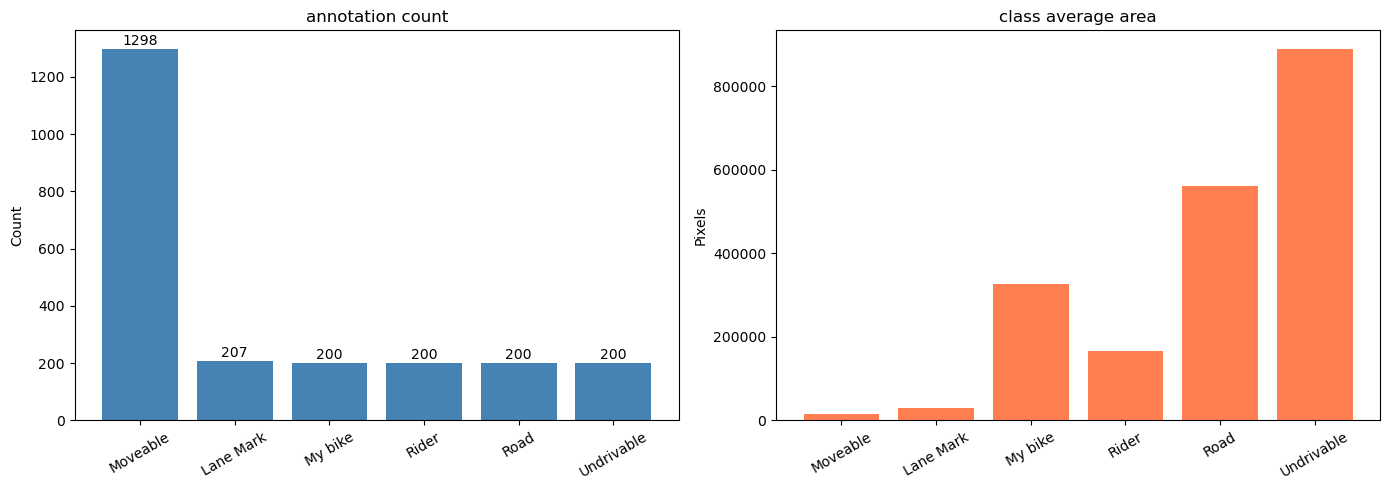

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# (1) 개수 막대그래프
# 컬럼명은 한글로 두고, bar 레이블만 영어로
axes[0].bar(df_stats['클래스'], df_stats['count'], color='steelblue')
axes[0].set_title('annotation count', fontsize=12)
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=30)
# 막대 위에 숫자 표시
for i, v in enumerate(df_stats['count']):
    axes[0].text(i, v + max(df_stats['count'])*0.01, str(v), ha='center', fontsize=10)

# (2) 평균 면적 막대그래프
axes[1].bar(df_stats['클래스'], df_stats['평균면적'], color='coral')
axes[1].set_title('class average area', fontsize=12)
axes[1].set_ylabel('Pixels')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

### 당연하지만 예상대로 차량인 무버블이 1298로 가장 카운팅이 많았고, 비주행구역인 언드라이버블의 면적이 제일 많았다.

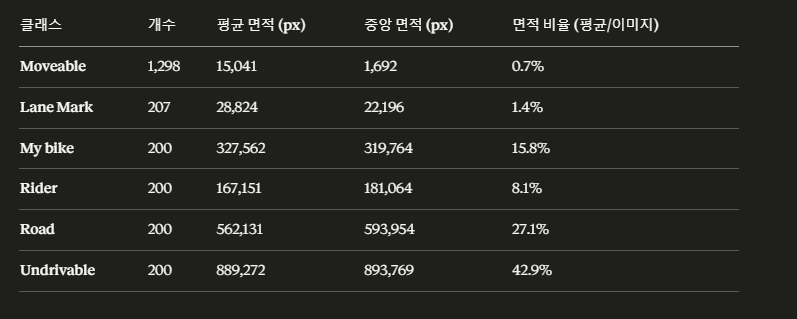

### 현재 얻은 데이터를 통해서 분석 가능한것.  

마 바이크, 라이더, 로드, 언드라이버블은 모든 사진당 1개씩 카운팅 되었음.  
레인마크는 207개로 당장 사진 하나 골라잡아도 2개 이상으로 보이는데 왜 이렇게 나온지 모르겟음. 회의 ㄱㄱ  
무버블은 1,298개로 사진당 평균 6대 좀 넘는 차량이 찍혔다고 가정할 수 있음.

### 가설 검증을 위한 레인 마크가 사진당 몇개 있는지 확인

In [10]:
# 프레임별 Lane Mark 개수 집계
lane_mark_cat_id = [cat['id'] for cat in coco['categories'] if cat['name'] == 'Lane Mark'][0]

per_frame_lane_count = Counter()
for ann in coco['annotations']:
    if ann['category_id'] == lane_mark_cat_id:
        per_frame_lane_count[ann['image_id']] += 1

# 프레임당 개수 분포
# 레인마크 아예없는것도 있을 수 있으니 전체 이미지 기준으로 집계
all_image_ids = [img['id'] for img in coco['images']]
distribution = Counter()
for img_id in all_image_ids:
    count = per_frame_lane_count.get(img_id, 0)
    distribution[count] += 1

print('사진당 레인마크 갯수 확인')
for count, freq in sorted(distribution.items()):
    print(f'레인마크 {count}개: {freq}장')

print(f'\n총 레인마크: {sum(per_frame_lane_count.values())}개')
print(f'평균: {sum(per_frame_lane_count.values()) / 200:.3f}개')

사진당 레인마크 갯수 확인
레인마크 0개: 3장
레인마크 1개: 193장
레인마크 2개: 3장
레인마크 8개: 1장

총 레인마크: 207개
평균: 1.035개


### 마스크 시각화 시작

파이코코툴즈 설치

In [11]:
!pip install pycocotools

^C
ERROR: Operation cancelled by user


코코 api 로드 및 클래스 색 지정  
라이더는 빨강, 내 바이크는 파랑, 무버블은 초록, 레인 마크는 노랑, 로드는 회색, 언드라이버블은 주황

In [12]:
from pycocotools.coco import COCO
from matplotlib.patches import Patch

# coco 객체 만들기 (얘가 polygon 다 처리해줌)
coco_api = COCO(ANNOTATION_FILE)

# 클래스별 색깔 미리 정해두기 (rgb, 0~255)
# 나중에 학습 마스크 만들때도 여기에 맞춰서 클래스 id 매핑
# 눈에 잘 띄는 색으로 골랐음
CLASS_COLORS = {
    'Rider':      (255, 100, 100), # 빨강
    'My bike':    (100, 100, 255), # 파랑
    'Moveable':   (100, 255, 100), # 초록
    'Lane Mark':  (255, 255, 100), # 노랑
    'Road':       (180, 180, 180), # 회색
    'Undrivable': (255, 180, 100), # 주황
}

# 클래스 이름 -> id 매핑 (반대방향도 필요할때가 있어서)
cat_name_to_id = {v: k for k, v in cat_id_to_name.items()}

print('클래스 매핑 준비됨')

loading annotations into memory...



KeyboardInterrupt



### 마스크 시각화 함수

In [ ]:
def visualize_annotations(image_id, alpha=0.5):
    # 이미지 정보 꺼내기
    img_info = coco_api.loadImgs(image_id)[0]
    img_path = os.path.join(IMAGE_DIR, img_info['file_name'])
    img = np.array(Image.open(img_path).convert('RGB'))
    
    # 이 이미지에 달린 모든 annotation 가져오기
    ann_ids = coco_api.getAnnIds(imgIds=image_id)
    anns = coco_api.loadAnns(ann_ids)
    
    # 오버레이용 빈 캔버스 (원본 복사해서 그위에 색칠할거임)
    overlay = img.copy()
    
    # annotation 하나씩 돌면서 마스크 그리기
    for ann in anns:
        # polygon -> binary mask (h, w) 로 변환. 이게 pycocotools 핵심 기능
        mask = coco_api.annToMask(ann)
        cat_name = cat_id_to_name[ann['category_id']]
        color = CLASS_COLORS.get(cat_name, (255, 255, 255))
        # 마스크 1인 픽셀만 색깔로 덧칠
        overlay[mask == 1] = color
    
    # 원본이랑 오버레이 알파블렌딩 (반투명 효과)
    blended = (img * (1 - alpha) + overlay * alpha).astype(np.uint8)
    
    return img, blended, img_info['file_name'], len(anns)

### 확인용 샘플 3장 시각화

In [ ]:
# 샘플 3장: 처음, 중간, 끝쪽
sample_image_ids = [coco['images'][i]['id'] for i in [0, 100, 199]]

fig, axes = plt.subplots(3, 2, figsize=(16, 14))
for row, img_id in enumerate(sample_image_ids):
    original, blended, fname, n_anns = visualize_annotations(img_id)
    
    axes[row, 0].imshow(original)
    axes[row, 0].set_title(f'Original: {fname}', fontsize=10)
    axes[row, 0].axis('off')
    
    axes[row, 1].imshow(blended)
    axes[row, 1].set_title(f'Overlay ({n_anns} annotations)', fontsize=10)
    axes[row, 1].axis('off')

# 하단에 범례 (어느 색이 어느 클래스인지)
legend_patches = [Patch(facecolor=np.array(c)/255, label=name) 
                  for name, c in CLASS_COLORS.items()]
fig.legend(handles=legend_patches, loc='lower center', 
           ncol=6, bbox_to_anchor=(0.5, -0.02), fontsize=10)

plt.tight_layout()
plt.show()

## 테스트로 얻은 것들.  

일단 대분류로 되어있는 6개 클래스 다 정확하게 잘찍힌 것을 확인.  
폴리곤 -> 마스크 변환 파이프라인 잘 작동함.
첫번째 샘플의 사진에서는 사람의 눈에도 잘 보이지 않은 멀리 있는 차량을 잡아주는 것을 확인함. 샘플 품질이 아주 좋다는 것을 확인.  
이걸로 먼 무버블이랑 가까운 무버블 구분이 가능하다는 것을 발견

### 라벨 마스크 생성함수  
일단 시각화용 오버레이는 끝  
학습용 라벨 마스크 제작 시작

### 클래스 아이디 재매핑  
AI의 조언, 카테고리 아이디가 6자리의 큰숫자라서 모델 학습할때 에로 사항이 생긴다고함.
중요한거로는 0부터 시작하는 연속된 정수여야 파이토치 로스가 제대로 작동한다고함.  


In [ ]:
# 원래 coco id -> 새 id (0~5) 매핑
# 클래스 이름 순서는 님이 중요하다고 생각하는 순서로. 일단 카운트 많은 순
CLASS_ORDER = ['Moveable', 'Lane Mark', 'My bike', 'Rider', 'Road', 'Undrivable']

# 새 id 할당 (0=background, 1~6=클래스들)
# background는 안쓸 예정이지만 관습상 남겨둠
NEW_ID_MAP = {}   # old_coco_id -> new_id
NAME_TO_NEW_ID = {'background': 0}

for idx, name in enumerate(CLASS_ORDER, start=1):
    old_id = cat_name_to_id[name]
    NEW_ID_MAP[old_id] = idx
    NAME_TO_NEW_ID[name] = idx

print('id 재매핑 결과')
print(f'  background      -> 0 (안쓰지만 혹시몰라서)')
for name in CLASS_ORDER:
    old = cat_name_to_id[name]
    new = NAME_TO_NEW_ID[name]
    print(f'  {name:12s} (coco id={old}) -> {new}')

# 총 클래스 수 (모델 output 채널수로 쓸거임)
NUM_CLASSES = len(CLASS_ORDER) + 1  # +1 은 background
print(f'\n총 클래스 수 (bg 포함): {NUM_CLASSES}')

### 라벨 마스크 생성 함수

In [ ]:
def create_label_mask(image_id):
    # 이미지 크기 확인
    img_info = coco_api.loadImgs(image_id)[0]
    h, w = img_info['height'], img_info['width']
    
    # 배경값 0으로 초기화된 빈 캔버스
    label_mask = np.zeros((h, w), dtype=np.uint8)
    
    # annotation들 가져오기
    ann_ids = coco_api.getAnnIds(imgIds=image_id)
    anns = coco_api.loadAnns(ann_ids)
    
    # 면적 큰거 먼저 그리기 (작은게 나중에 덮어써서 살아남게)
    # 배경이 될만한 큰애들(road, undrivable)을 먼저 깔고
    # 그위에 작은애들(lane mark, moveable) 얹는 순서
    anns_sorted = sorted(anns, key=lambda a: a['area'], reverse=True)
    
    for ann in anns_sorted:
        binary_mask = coco_api.annToMask(ann)   # 0과 1로만 된 마스크
        new_id = NEW_ID_MAP[ann['category_id']]
        # 해당 픽셀들에 클래스 id 찍기
        label_mask[binary_mask == 1] = new_id
    
    return label_mask

# 테스트: 한장 만들어보기
sample_id = coco['images'][0]['id']
test_mask = create_label_mask(sample_id)

print(f'마스크 shape: {test_mask.shape}')
print(f'마스크 dtype: {test_mask.dtype}')
print(f'포함된 고유값: {np.unique(test_mask).tolist()}')
print(f'최소/최대: {test_mask.min()} / {test_mask.max()}')

# 클래스별 픽셀 수
print('\n픽셀별 분포:')
for val in np.unique(test_mask):
    count = (test_mask == val).sum()
    ratio = count / test_mask.size * 100
    name = [n for n, nid in NAME_TO_NEW_ID.items() if nid == val][0]
    print(f'  id={val} ({name:12s}): {count:>8,} px ({ratio:5.2f}%)')

### 생성된 라벨 마스크 시각화 테스트

In [ ]:
from matplotlib.colors import ListedColormap

colors_list = [(0, 0, 0)]  # 배경 검정
for name in CLASS_ORDER:
    c = CLASS_COLORS[name]
    colors_list.append([x/255 for x in c])

cmap = ListedColormap(colors_list)

# 샘플 3장 비교
sample_image_ids = [coco['images'][i]['id'] for i in [0, 100, 199]]

fig, axes = plt.subplots(3, 3, figsize=(20, 12))
for row, img_id in enumerate(sample_image_ids):
    # 원본이랑 오버레이
    original, blended, fname, n_anns = visualize_annotations(img_id)
    # 새로 만든 label mask
    label_mask = create_label_mask(img_id)
    
    axes[row, 0].imshow(original)
    axes[row, 0].set_title(f'Original: {fname}', fontsize=9)
    axes[row, 0].axis('off')
    
    axes[row, 1].imshow(blended)
    axes[row, 1].set_title(f'Visualization overlay', fontsize=9)
    axes[row, 1].axis('off')
    
    axes[row, 2].imshow(label_mask, cmap=cmap, vmin=0, vmax=NUM_CLASSES-1)
    axes[row, 2].set_title(f'Label mask (for training)', fontsize=9)
    axes[row, 2].axis('off')

plt.tight_layout()
plt.show()

## 데이터셋 클래스

필요 라이브러리 불러오기 및 gpu 모델 확인.

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from sklearn.model_selection import train_test_split

# 현재 사용중인 gpu 확인. 학원에서는 좋은 gpu라고 햇음.
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'device: {device}')
if device.type == 'cuda':
    print(f'gpu name: {torch.cuda.get_device_name()}')

In [ ]:
train_ids = [img['id'] for img in coco['images']]
print(f'train: {len(train_ids)}개 (전체 200장)')
print(f'val: 나중에 팀에서 별도 데이터 업로드 예정')

# 학습 중간 점검용 샘플 3개 지정 (얘네도 학습에 참여함. 단순히 모니터링용)
# 골고루 Screenshot이랑 night ride 에서 하나씩 섞어서
monitoring_ids = []
for img_info in coco['images']:
    if img_info['file_name'] == 'Screenshot (309).png':
        monitoring_ids.append(img_info['id'])
        break
for img_info in coco['images']:
    if img_info['file_name'] == 'night ride (10).png':
        monitoring_ids.append(img_info['id'])
        break
for img_info in coco['images']:
    if img_info['file_name'] == 'Screenshot (361).png':
        monitoring_ids.append(img_info['id'])
        break

print(f'\n모니터링용 샘플 {len(monitoring_ids)}개 (학습 진척도 시각화용)')

### 데이터셋 클래스

In [ ]:
# pytorch dataset 클래스 구현
# __len__ 이랑 __getitem__ 두개만 구현
# image_id 리스트를 보관
# 인덱스 요청 오면 해당 (이미지, 마스크) 쌍을 텐서로 리턴
# 리사이즈도 여기서 처리

class MotorcycleNightDataset(Dataset):
    def __init__(self, image_ids, coco_api, image_dir, 
                 img_size=256, augment=False):
        # 학습에 쓸 이미지 id들 (train 또는 val)
        self.image_ids = image_ids
        self.coco_api = coco_api
        self.image_dir = image_dir
        self.img_size = img_size
        self.augment = augment   # 나중에 쓸지도 모르니 받아만 둠
        
        # 이미지 변환 파이프라인 정의
        # 순서: pil -> tensor -> normalize
        # imagenet 평균/표준편차로 정규화. 사전학습 모델 쓸때 관습
        self.img_transform = transforms.Compose([
            transforms.Resize((img_size, img_size)),   # 정사각형으로
            transforms.ToTensor(),                      # 0~255 -> 0.0~1.0
            transforms.Normalize(
                mean=[0.485, 0.456, 0.406],             # imagenet rgb 평균
                std=[0.229, 0.224, 0.225],              # imagenet rgb 표준편차
            ),
        ])
    
    def __len__(self):
        # dataloader 가 몇개 돌려야되는지 알려면 이걸 구현해야됨
        return len(self.image_ids)
    
    def __getitem__(self, idx):
        # idx 번째 데이터 한쌍 반환
        image_id = self.image_ids[idx]
        
        # 이미지 로드
        img_info = self.coco_api.loadImgs(image_id)[0]
        img_path = os.path.join(self.image_dir, img_info['file_name'])
        image = Image.open(img_path).convert('RGB')
        
        # 마스크 생성 (우리가 앞에서 만든 함수 재사용)
        label_mask = create_label_mask(image_id)   # (h, w) np array
        
        # 이미지 변환 (리사이즈 + 텐서 + 정규화)
        image_tensor = self.img_transform(image)   # (3, 256, 256)
        
        # 마스크도 같은 크기로 리사이즈
        # 주의: 마스크는 nearest neighbor로 해야됨. bilinear 쓰면 
        #       정수값이 3.4 같은 실수로 망가짐 (클래스 id는 정수여야함!)
        mask_pil = Image.fromarray(label_mask)
        mask_resized = mask_pil.resize(
            (self.img_size, self.img_size),
            Image.NEAREST   # 이게 중요!
        )
        # 텐서로 변환. long (정수) 타입이어야 crossentropy loss 가 먹음
        mask_tensor = torch.from_numpy(np.array(mask_resized)).long()
        
        return image_tensor, mask_tensor

# 학습 dataset 인스턴스 만들기
train_dataset = MotorcycleNightDataset(train_ids, coco_api, IMAGE_DIR, img_size=256)
# val_dataset = MotorcycleNightDataset(val_ids, coco_api, IMAGE_DIR, img_size=256) # 나중에 시험 데이터 들어오면
print(f'train_dataset 크기: {len(train_dataset)}')

# 샘플 하나 꺼내서 shape 확인
img, msk = train_dataset[0]
print(f'\n샘플 확인:')
print(f'  image shape: {img.shape}, dtype: {img.dtype}')
print(f'  mask shape : {msk.shape}, dtype: {msk.dtype}')
print(f'  mask 고유값: {torch.unique(msk).tolist()}')

### 데이터셋 시각화 테스트

In [ ]:
# 마스크는 cmap 적용해서 색깔로 보여주기

def denormalize(img_tensor):
    # imagenet 역정규화 (보여줄때만 씀)
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    return (img_tensor * std + mean).clamp(0, 1)

# 3개 샘플 확인
fig, axes = plt.subplots(3, 2, figsize=(10, 12))
for row in range(3):
    img_t, msk_t = train_dataset[row]
    # 텐서 -> numpy 로 바꿔서 그리기
    img_np = denormalize(img_t).permute(1, 2, 0).numpy()
    msk_np = msk_t.numpy()
    
    axes[row, 0].imshow(img_np)
    axes[row, 0].set_title(f'Image (tensor shape: {tuple(img_t.shape)})', fontsize=9)
    axes[row, 0].axis('off')
    
    axes[row, 1].imshow(msk_np, cmap=cmap, vmin=0, vmax=NUM_CLASSES-1)
    axes[row, 1].set_title(f'Mask (shape: {tuple(msk_t.shape)}, classes: {torch.unique(msk_t).tolist()})', 
                          fontsize=9)
    axes[row, 1].axis('off')

plt.tight_layout()
plt.show()

### 데이터로더 제작  
데이서셋을 배치 단위로 묶어주는 역할  
학습할때 1장씩 넣으면 효율이 안나오니까 여러장 지금은 8장 터지면 4장으로 묶어서 병렬 처리

In [ ]:
BATCH_SIZE = 8

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,           # 학습 데이터는 매 에폭마다 섞기
    num_workers=2,          # 데이터 로딩 병렬. 0이면 메인 프로세스에서만
    pin_memory=True,        # gpu 전송 빠르게 해줌 (cuda 쓸때만)
)

# val_loader 는 팀에서 별도 데이터 받으면 만들예정
# val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, ...)

print(f'train_loader: {len(train_loader)} batches')

# 한 배치 꺼내서 shape 확인
# 여기서 shape 이상하면 dataset 쪽에 문제 있는거니까 꼭 점검하고 넘어가야함
images, masks = next(iter(train_loader))
print(f'\n배치 shape 확인:')
print(f'  images: {images.shape}')       # (8, 3, 256, 256) 이어야함
print(f'  masks : {masks.shape}')        # (8, 256, 256) 이어야함
print(f'  masks dtype: {masks.dtype}')   # int64 (long) 이어야함
print(f'  masks 고유값: {torch.unique(masks).tolist()}')  # 0~6 범위 안이어야함

### U-Net 모델 구현

#### 유넷을 선택한 이유  
- 입문용으로 가장 많이 추천되었다.
- 의료 영상 분할에서 2015년부터 표준으로 쓰일 정도로 신뢰도가 높다.
- 우리가 가지고 있는 데이터량이 200장밖에 안되는데 여기서도 잘 작동함 <-- 이게 가장 큼

유넷의 구조 짧은 요약 : conv -> batchnorm -> relu -> conv -> batchnorm -> relu

### 클래스 정의 -1

In [ ]:
class DoubleConv(nn.Module):
    """3x3 conv 두번 + batchnorm + relu 하는 블록"""
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = nn.Sequential(
            # 첫번째 conv
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            # 두번째 conv
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )
    
    def forward(self, x):
        return self.conv(x)

### 클래스 정의 -2

In [ ]:
class UNet(nn.Module):
    def __init__(self, in_channels=3, num_classes=7):
        super().__init__()
        
        # ===== encoder (내려가는 부분) =====
        # 점점 채널수 늘리면서 공간 크기는 절반씩 줄임
        self.enc1 = DoubleConv(in_channels, 64)    # 256x256 -> 256x256 (채널만 증가)
        self.enc2 = DoubleConv(64, 128)            # 128x128 -> 128x128
        self.enc3 = DoubleConv(128, 256)           # 64x64
        self.enc4 = DoubleConv(256, 512)           # 32x32
        
        # 공간 크기 줄이는 놈. 풀링이 맡음
        self.pool = nn.MaxPool2d(2)
        
        # ===== bottleneck (U자 맨 아래) =====
        self.bottleneck = DoubleConv(512, 1024)    # 16x16
        
        # ===== decoder (올라가는 부분) =====
        # upsample 이 공간 크기 두배로 늘려주고, 그다음 concat 후 conv
        # transposed conv 로 업샘플링. 학습 가능한 파라미터 있어서 bilinear 보다 유연
        self.up4 = nn.ConvTranspose2d(1024, 512, kernel_size=2, stride=2)
        self.dec4 = DoubleConv(1024, 512)   # 입력 1024 = 업샘플된 512 + skip 512
        
        self.up3 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.dec3 = DoubleConv(512, 256)
        
        self.up2 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.dec2 = DoubleConv(256, 128)
        
        self.up1 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.dec1 = DoubleConv(128, 64)
        
        # ===== 최종 출력 =====
        # 1x1 conv 로 채널수를 클래스 개수로 만들어줌
        # 각 픽셀마다 7개 클래스에 대한 점수가 나옴
        self.out_conv = nn.Conv2d(64, num_classes, kernel_size=1)
    
    def forward(self, x):
        # ===== encoder 진행 =====
        # 나중에 skip connection 할라고 중간 결과 저장해둠
        e1 = self.enc1(x)                    # (b, 64, 256, 256)
        e2 = self.enc2(self.pool(e1))        # (b, 128, 128, 128)
        e3 = self.enc3(self.pool(e2))        # (b, 256, 64, 64)
        e4 = self.enc4(self.pool(e3))        # (b, 512, 32, 32)
        
        # ===== bottleneck =====
        b = self.bottleneck(self.pool(e4))   # (b, 1024, 16, 16)
        
        # ===== decoder 진행 + skip connection =====
        # torch.cat 으로 채널 방향으로 이어붙임 (dim=1)
        d4 = self.up4(b)                     # (b, 512, 32, 32)
        d4 = self.dec4(torch.cat([d4, e4], dim=1))   # e4 가 skip
        
        d3 = self.up3(d4)
        d3 = self.dec3(torch.cat([d3, e3], dim=1))
        
        d2 = self.up2(d3)
        d2 = self.dec2(torch.cat([d2, e2], dim=1))
        
        d1 = self.up1(d2)
        d1 = self.dec1(torch.cat([d1, e1], dim=1))
        
        # ===== 최종 logit =====
        # 아직 softmax 안걸었음. loss 가 알아서 처리함 (crossentropy 가 logit 받음)
        out = self.out_conv(d1)              # (b, num_classes, 256, 256)
        return out

### 모델 생성및 배치 통과 시키고 쉐이프 체크

In [ ]:
model = UNet(in_channels=3, num_classes=NUM_CLASSES).to(device)

# 파라미터 개수 확인 (클수록 학습 오래걸림)
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'총 파라미터: {total_params:,}')
print(f'학습 가능 파라미터: {trainable_params:,}')

# 테스트: 배치 하나 통과시켜보기
# no_grad 는 그냥 shape 확인용이라 그래디언트 계산 안할거라 메모리 아끼려고
model.eval()
with torch.no_grad():
    test_images, test_masks = next(iter(train_loader))
    test_images = test_images.to(device)
    
    output = model(test_images)
    
    print(f'\n=== 모델 forward 확인 ===')
    print(f'입력 shape : {test_images.shape}')
    print(f'출력 shape : {output.shape}')
    print(f'  -> (배치, 클래스, 높이, 너비) 순서')
    print(f'  -> 클래스 차원({output.shape[1]})이 NUM_CLASSES({NUM_CLASSES})랑 같아야함')

model.train()

### 로스 함수 정의  
loss 함수. 세그멘테이션의 표준인 crossentropy 사용

In [ ]:
criterion = nn.CrossEntropyLoss()

# 테스트: 한 배치로 loss 한번 계산해봐서 값이 제대로 나오는지 확인
# 이상치로는 둘다 1.95 근처로 나와야 정상
# (7개 클래스를 균등 확률로 찍었을때 이론적 loss)
model.eval()
with torch.no_grad():
    imgs, msks = next(iter(train_loader))
    imgs, msks = imgs.to(device), msks.to(device)
    
    out = model(imgs) # (8, 7, 256, 256)
    loss = criterion(out, msks)
    
    print(f'초기 loss: {loss.item():.4f}')
    print(f'이론적 기대값: log(7) = {np.log(7):.4f}')

다행스럽게도 두값이 비슷한 것을 확인

### IoU 메트릭 함수

In [ ]:
def compute_iou(preds, targets, num_classes):
    """
    preds: (b, h, w) 예측 클래스 id (argmax 적용된 상태)
    targets: (b, h, w) 정답 클래스 id
    
    반환: 클래스별 iou 리스트. 해당 클래스가 없으면 nan
    """
    ious = []
    preds = preds.view(-1)      # 1d 로 펴기
    targets = targets.view(-1)
    
    for cls in range(num_classes):
        # 해당 클래스 영역의 바이너리 마스크
        pred_cls = (preds == cls)
        target_cls = (targets == cls)
        
        intersection = (pred_cls & target_cls).sum().item()
        union = (pred_cls | target_cls).sum().item()
        
        if union == 0:
            # 배치에 이 클래스 자체가 없는 경우
            ious.append(float('nan'))
        else:
            ious.append(intersection / union)
    
    return ious


# 테스트: 무작위 초기 모델로 iou 찍어봄. 당연히 낮게 나올거임 (학습 전이니까)
model.eval()
with torch.no_grad():
    imgs, msks = next(iter(train_loader))
    imgs, msks = imgs.to(device), msks.to(device)
    
    logits = model(imgs)                   # (8, 7, 256, 256)
    preds = torch.argmax(logits, dim=1)    # (8, 256, 256)
    
    ious = compute_iou(preds, msks, NUM_CLASSES)
    
    # 클래스 이름이랑 같이 출력
    class_names = ['background'] + CLASS_ORDER
    print('학습 전 iou')
    for i, (name, iou) in enumerate(zip(class_names, ious)):
        if np.isnan(iou):
            print(f'  id={i} {name:12s}: nan (이 배치에 없음)')
        else:
            print(f'  id={i} {name:12s}: {iou:.4f}')
    
    # nan 제외한 평균
    valid_ious = [i for i in ious if not np.isnan(i)]
    print(f'\nmIoU: {np.mean(valid_ious):.4f}')

### 학습 전이라 당연히 IoU가 낮은 것을 확인함.

### 현재 값 2%, 학습후 최소 40에서 70%가 첫번째 목표값으로 지정  
마이 바이크와 라이더는 사실 예측이 된것이 화면의 거의 3분에 1을 차지하는 거라서 운좋게 찍어서 그영역에 맞추고 클래스로 분류될 가능성이 상당히 높았음.

# 학습전 우리의 학습 엔진 구조 설명
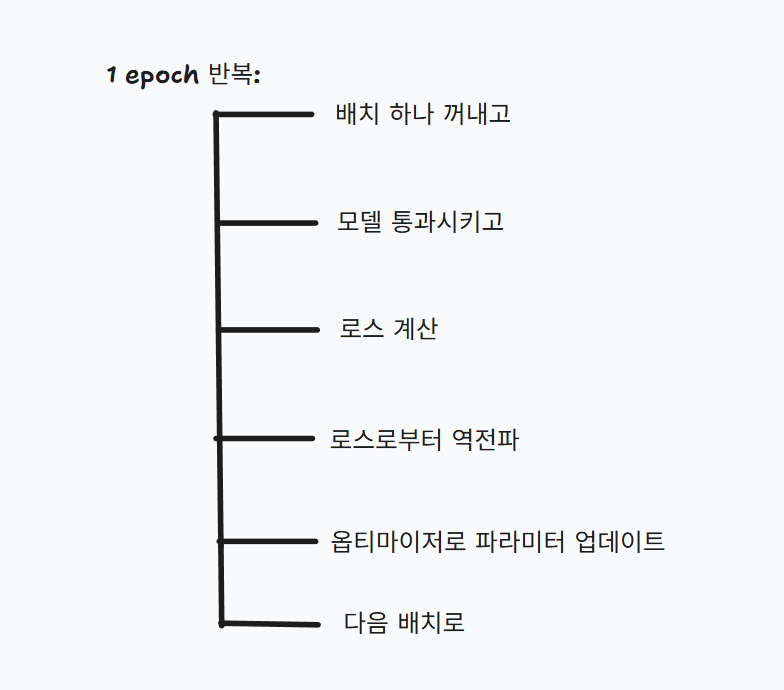

### 이제 필요한 것
옵티마이저 - 아담 사용   
활성화 함수 - 렐루  
검증 함수(val 데이터 오면 사용할 거라 미리 만듬)  
로그 기록 에폭별 로스랑 iou저장  
시각화 점검 몇 에폭마다 예측결과를 눈으로 확인하기 위해서

### 옵티마이저랑 하이퍼 파라미터 세팅

In [ ]:
# 입문용으로 좋다고 추천받은 아담을 사용할 예정, lr은 1e~4에서 시작함. 이것도 추천받음.

LEARNING_RATE = 1e-4
NUM_EPOCHS = 30

# optimizer: adam
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

# 학습 기록 저장할 딕셔너리
# 에폭별로 loss, mIoU 저장해놓고 나중에 그래프로 그릴거임
history = {
    'epoch': [],
    'train_loss': [],
    'train_miou': [],
}

print(f'learning rate: {LEARNING_RATE}')
print(f'epochs: {NUM_EPOCHS}')
print(f'optimizer: {type(optimizer).__name__}')
print(f'criterion: {type(criterion).__name__}')

### 학습 함수와 평가함수

In [ ]:
# 에포크 돌리는 함수들
# 나중에 학습 루프에서 에폭마다 호출
# 함수로 빼두면 나중에 실험 여러개 할대 재사용 가능

def train_one_epoch(model, loader, criterion, optimizer, device, num_classes):
    """1 epoch 학습. 평균 loss 랑 mIoU 반환"""
    model.train()
    
    total_loss = 0
    # 전체 iou 누적용. 배치마다 iou 구해서 평균내는 방식
    all_ious = []   # 리스트에 모아놨다가 마지막에 평균
    
    for images, masks in loader:
        images = images.to(device)
        masks = masks.to(device)
        
        # forward
        logits = model(images)               # (b, c, h, w)
        loss = criterion(logits, masks)
        
        # backward + 파라미터 업데이트
        optimizer.zero_grad()   # 이전 gradient 초기화 (안하면 누적됨)
        loss.backward()         # 역전파
        optimizer.step()        # 실제 업데이트
        
        # 통계 누적
        total_loss += loss.item()
        
        # iou 는 예측이랑 정답으로 계산
        with torch.no_grad():
            preds = torch.argmax(logits, dim=1)
            batch_ious = compute_iou(preds, masks, num_classes)
            all_ious.append(batch_ious)
    
    # 평균 loss
    avg_loss = total_loss / len(loader)
    
    # mIoU: 클래스별로 평균 낸 다음 전체 평균
    # nan 제외하고 계산
    all_ious = np.array(all_ious)   # (num_batches, num_classes)
    # 각 클래스의 평균 (nan 무시)
    class_miou = np.nanmean(all_ious, axis=0)   # (num_classes,)
    # 전체 평균
    miou = np.nanmean(class_miou)
    
    return avg_loss, miou, class_miou


def evaluate(model, loader, criterion, device, num_classes):
    """검증용 함수. 나중에 val 데이터 받으면 씀"""
    model.eval()
    
    total_loss = 0
    all_ious = []
    
    with torch.no_grad():
        for images, masks in loader:
            images = images.to(device)
            masks = masks.to(device)
            
            logits = model(images)
            loss = criterion(logits, masks)
            
            total_loss += loss.item()
            preds = torch.argmax(logits, dim=1)
            batch_ious = compute_iou(preds, masks, num_classes)
            all_ious.append(batch_ious)
    
    avg_loss = total_loss / len(loader)
    all_ious = np.array(all_ious)
    class_miou = np.nanmean(all_ious, axis=0)
    miou = np.nanmean(class_miou)
    
    return avg_loss, miou, class_miou

### 첫 학습 시작

In [ ]:
# 일단 시작이니까 가볍게 30에폭 ㄱㄱ
# 에폭마다 로스랑 miou 출력해서 진척도 확인 할 수 있게 추가
# 히스토리에도 저장해서 나중에 그래프 작성할거임
# 소요시간 확인할 수 있게 출력 단위 분

import time

class_names = ['background'] + CLASS_ORDER

print('학습 시작')

start_time = time.time()

for epoch in range(1, NUM_EPOCHS + 1):
    epoch_start = time.time()
    
    # 한 에폭 학습
    train_loss, train_miou, train_class_miou = train_one_epoch(
        model, train_loader, criterion, optimizer, device, NUM_CLASSES
    )
    
    epoch_time = time.time() - epoch_start
    
    # 기록 저장
    history['epoch'].append(epoch)
    history['train_loss'].append(train_loss)
    history['train_miou'].append(train_miou)
    
    # 출력 (5 에폭마다 클래스별 iou 상세, 그외에는 요약만)
    if epoch % 5 == 0 or epoch == 1:
        print(f'\n[ Epoch {epoch}/{NUM_EPOCHS} ]  time: {epoch_time:.1f}s')
        print(f'  train loss: {train_loss:.4f}')
        print(f'  train mIoU: {train_miou:.4f}')
        print(f'  클래스별 iou:')
        for name, iou in zip(class_names, train_class_miou):
            print(f'    {name:12s}: {iou:.4f}' if not np.isnan(iou) else f'    {name:12s}: nan')
    else:
        print(f'Epoch {epoch:2d}/{NUM_EPOCHS}  '
              f'loss: {train_loss:.4f}  mIoU: {train_miou:.4f}  '
              f'({epoch_time:.1f}s)')

total_time = time.time() - start_time
print(f'\n총 소요시간{total_time/60:.1f}분')

### 학습 곡선 시각화

생각보다 결과가 잘나왔다. 목표치보다 높게 나왔다.

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# loss 곡선
axes[0].plot(history['epoch'], history['train_loss'], 'b-o', markersize=4)
axes[0].set_title('Training Loss over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Cross Entropy Loss')
axes[0].grid(True, alpha=0.3)

# mIoU 곡선
axes[1].plot(history['epoch'], history['train_miou'], 'g-o', markersize=4)
axes[1].set_title('Training mIoU over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('mIoU')
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()

# 최종 결과 요약
print('\n최종 결과')
print(f'마지막 train loss: {history["train_loss"][-1]:.4f}')
print(f'마지막 train mIoU: {history["train_miou"][-1]:.4f}')
print(f'최고 mIoU: {max(history["train_miou"]):.4f} (epoch {np.argmax(history["train_miou"])+1})')

## 로스는 내려가고, 정확도는 올라가는것을 시각화  
이것으로 얻을수 있는 정보  
- 로스 곡선은 5에폭에서 급격하게 감소 이후 완만해짐
- 과적합의 징후가 없음
- 엠아이오유 곡선은 0.2쯤에서 0.7 가까이 상승함
- 곡선이 완만하진 않지만 더 올라갈 여지가 있어보임.

### 클래스별 정확도 분석
언드라이버블 - 96% (예상 범위 내)  
마이 바이크 - 94% (예상 범위 내)  
라이더 - 93% (예상 범위 내)  
로드 - 89% (예상 범위 내)  
무버블 - 78%  
래인마크 - 37%  
백그라운드(그외것) - 0% (정확한 예상값)

#### My bike, Rider는 공간적으로 고정된 객체라서 맞추기 쉬웠을거라고 판단 당연한 결과  
#### Undrivable는 맨 위에서 분석했듯이 이미지의 42.9%가 이 클래스 원래 제일 많은 클래스라 맞추기 쉬웠음으로 예상  
#### Moveable은 중간 차들이 위치가 계속 바뀌고 크기도 제각각인데 이 정도면 선방했다고 생각함.  
#### Lane Mark는 이렇게 낮게 나올줄 몰랐음. 하지만 예상된 결과이기도 한데, EDA때 분석했듯이 전체 면적 비율에서 1.4%로 굉장히 낮은 비율을 보여주었음. 픽셀로도 작은편이었고


### 결과의 시각화

In [ ]:
model.eval()

# 배치 하나 꺼내서 예측
with torch.no_grad():
    images, masks = next(iter(train_loader))
    images_gpu = images.to(device)
    
    logits = model(images_gpu)                    # (8, 7, 256, 256)
    preds = torch.argmax(logits, dim=1).cpu()     # (8, 256, 256) 정수

# 4장 시각화
n_samples = 4
fig, axes = plt.subplots(n_samples, 3, figsize=(15, 5 * n_samples))

for i in range(n_samples):
    # 원본 이미지
    img_denorm = denormalize(images[i]).permute(1, 2, 0).numpy()
    # 정답 마스크
    gt_mask = masks[i].numpy()
    # 우리 모델 마스크
    pred_mask = preds[i].numpy()
    
    axes[i, 0].imshow(img_denorm)
    axes[i, 0].set_title(f'Sample {i+1}: Input Image', fontsize=10)
    axes[i, 0].axis('off')
    
    axes[i, 1].imshow(gt_mask, cmap=cmap, vmin=0, vmax=NUM_CLASSES-1)
    axes[i, 1].set_title('answer', fontsize=10)
    axes[i, 1].axis('off')
    
    axes[i, 2].imshow(pred_mask, cmap=cmap, vmin=0, vmax=NUM_CLASSES-1)
    axes[i, 2].set_title('our model', fontsize=10)
    axes[i, 2].axis('off')

# 범례 하단에
legend_patches = [Patch(facecolor=c, label=name) 
                  for name, c in zip(
                      ['background'] + CLASS_ORDER,
                      colors_list)]
fig.legend(handles=legend_patches, loc='lower center', 
           ncol=7, bbox_to_anchor=(0.5, -0.01), fontsize=10)

plt.tight_layout()
plt.show()

### 왼쪽이 원본, 가운데가 정답 마스크, 오른쪽이 우리 모델

#### 더 잘보이게 원본 사진과 오버레이 추가

In [ ]:
def overlay_prediction(img_denorm, pred_mask, alpha=0.5):
    # 예측 마스크를 rgb 색으로 변환
    h, w = pred_mask.shape
    pred_rgb = np.zeros((h, w, 3), dtype=np.uint8)
    for class_id, color_arr in enumerate(colors_list):
        # colors_list 는 0~1 이라 255 곱해야 된다고 함.
        color_255 = (np.array(color_arr) * 255).astype(np.uint8)
        pred_rgb[pred_mask == class_id] = color_255
    
    # 원본도 uint8 로
    img_255 = (img_denorm * 255).astype(np.uint8)
    
    # 블렌딩
    blended = (img_255 * (1 - alpha) + pred_rgb * alpha).astype(np.uint8)
    return blended


fig, axes = plt.subplots(n_samples, 2, figsize=(12, 5 * n_samples))

for i in range(n_samples):
    img_denorm = denormalize(images[i]).permute(1, 2, 0).numpy()
    gt_mask = masks[i].numpy()
    pred_mask = preds[i].numpy()
    
    gt_overlay = overlay_prediction(img_denorm, gt_mask)
    pred_overlay = overlay_prediction(img_denorm, pred_mask)
    
    axes[i, 0].imshow(gt_overlay)
    axes[i, 0].set_title(f'sample {i+1}: answer', fontsize=10)
    axes[i, 0].axis('off')
    
    axes[i, 1].imshow(pred_overlay)
    axes[i, 1].set_title('our model', fontsize=10)
    axes[i, 1].axis('off')

plt.tight_layout()
plt.show()

### 주피터 커널 재시작 하면 다날아가는걸 방지하기 위한 모델 저장

In [ ]:
MODEL_SAVE_PATH = os.path.join(BASE_DIR, 'unet_baseline.pt')

torch.save({
    'model_state_dict': model.state_dict(),
    'history': history,
    'num_classes': NUM_CLASSES,
    'class_names': ['background'] + CLASS_ORDER,
    'final_miou': history['train_miou'][-1],
}, MODEL_SAVE_PATH)

print(f'모델 저장됨: {MODEL_SAVE_PATH}')
print(f'파일 크기: {os.path.getsize(MODEL_SAVE_PATH) / 1024 / 1024:.1f} MB')

# 나중에 이렇게 불러올수있음
# checkpoint = torch.load(MODEL_SAVE_PATH)
# model.load_state_dict(checkpoint['model_state_dict'])

# 이제 실전용 데이터(val)받고 성능 평가하면됨.

### 추가 중간 실험. 레인마크 적중률의 성능을 올려보기

분석은 위에서 했고 추천받은 솔루션
#### 1.레인 마크를 틀리면 더 큰 로스를 매긴다.

기존 모델 백업.

In [ ]:
import shutil

old_path = os.path.join(BASE_DIR, 'unet_baseline.pt')
full_backup_path = os.path.join(BASE_DIR, 'unet_full200.pt')

if os.path.exists(old_path):
    shutil.copy(old_path, full_backup_path)
    print(f'백업 완료: {full_backup_path}')
else:
    print('기존 파일 없음 (백업 불필요)')

print('\n앞으로 파일 이름 정리:')
print(f'unet_full200.pt : 200장 전체로 학습한거 (팀 val 용 예비)')
print(f'unet_baseline.pt : 앞으로 새로 만들 internal split 베이스라인')
print(f'unet_exp_XXX.pt : 개선 실험 모델들 (나중에)')

### train과 val 나누기 국룰로 8:2 (160:40)

In [ ]:
from sklearn.model_selection import train_test_split

all_image_ids = [img['id'] for img in coco['images']]

# 8:2 split
train_ids, val_ids = train_test_split(
    all_image_ids,
    test_size=0.2,
    random_state=42,        # 여기 바꾸지말것. 재현성 유지
    shuffle=True,
)

print(f'train : {len(train_ids)}개')
print(f'val : {len(val_ids)}개 (internal - 팀 val 아닌 우리가 쪼갠거)')

# 두 그룹(screenshot/night ride) 이 골고루 섞였는지 확인
def count_groups(ids):
    s = 0
    n = 0
    for img_info in coco['images']:
        if img_info['id'] in ids:
            if img_info['file_name'].lower().startswith('screenshot'):
                s += 1
            else:
                n += 1
    return s, n

tr_s, tr_n = count_groups(train_ids)
va_s, va_n = count_groups(val_ids)
print(f'\n섞임 확인')
print(f'train - screenshot: {tr_s}, night ride: {tr_n}')
print(f'val - screenshot: {va_s}, night ride: {va_n}')

### 데이터 셋과 데이터로더 재생성하기

In [ ]:
# 데이터셋 두개 만들기
# 이전코드에서 만든 motorcyclenightdataset 클래스 그대로 재사용
# 전과 바뀐것은 val_dataset 추가

train_dataset = MotorcycleNightDataset(train_ids, coco_api, IMAGE_DIR, img_size=256)
val_dataset = MotorcycleNightDataset(val_ids, coco_api, IMAGE_DIR, img_size=256)

print(f'train_dataset: {len(train_dataset)}')
print(f'val_dataset  : {len(val_dataset)}')

# dataloader 두개
BATCH_SIZE = 8

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,       # val 은 섞지 않음
    num_workers=2,
    pin_memory=True,
)

print(f'\ntrain_loader: {len(train_loader)} batches ({len(train_dataset)}장 / batch {BATCH_SIZE})')
print(f'val_loader : {len(val_loader)} batches ({len(val_dataset)}장 / batch {BATCH_SIZE})')

### 모델 새로 만들고 재학습

In [ ]:
# 모델 재생성
model = UNet(in_channels=3, num_classes=NUM_CLASSES).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
criterion = nn.CrossEntropyLoss()

# 기록용 (이번엔 val 도 저장)
history = {
    'epoch': [],
    'train_loss': [],
    'train_miou': [],
    'val_loss': [],
    'val_miou': [],
}

# 에폭마다 class 별 iou 도 저장 (lane mark 추이 보려고)
class_iou_history = {name: [] for name in ['background'] + CLASS_ORDER}

print(f'internal split 으로 베이스라인 재학습 시작')
print(f'train {len(train_dataset)}장 / val {len(val_dataset)}장')

start_time = time.time()

for epoch in range(1, NUM_EPOCHS + 1):
    epoch_start = time.time()
    
    # train
    train_loss, train_miou, _ = train_one_epoch(
        model, train_loader, criterion, optimizer, device, NUM_CLASSES
    )
    
    # val 평가
    val_loss, val_miou, val_class_miou = evaluate(
        model, val_loader, criterion, device, NUM_CLASSES
    )
    
    epoch_time = time.time() - epoch_start
    
    # 기록 저장
    history['epoch'].append(epoch)
    history['train_loss'].append(train_loss)
    history['train_miou'].append(train_miou)
    history['val_loss'].append(val_loss)
    history['val_miou'].append(val_miou)
    
    # 클래스별 iou 도 저장
    for name, iou in zip(['background'] + CLASS_ORDER, val_class_miou):
        class_iou_history[name].append(iou)
    
    # 출력 (매 에폭. 이번엔 train/val 나란히 보이게)
    if epoch % 5 == 0 or epoch == 1:
        print(f'\n[ Epoch {epoch:2d}/{NUM_EPOCHS} ]  time: {epoch_time:.1f}s')
        print(f'  train  loss: {train_loss:.4f}   mIoU: {train_miou:.4f}')
        print(f'  val    loss: {val_loss:.4f}    mIoU: {val_miou:.4f}')
        print(f'  val 클래스별 iou:')
        for name, iou in zip(['background'] + CLASS_ORDER, val_class_miou):
            s = f'    {name:12s}: {iou:.4f}' if not np.isnan(iou) else f'    {name:12s}: nan'
            # lane mark 는 눈에 띄게 표시
            if name == 'Lane Mark':
                s += '  개선 타겟'
            print(s)
    else:
        print(f'Epoch {epoch:2d}  '
              f'train loss/miou: {train_loss:.4f}/{train_miou:.4f}  |  '
              f'val loss/miou: {val_loss:.4f}/{val_miou:.4f}  '
              f'({epoch_time:.1f}s)')

total_time = time.time() - start_time
print(f'\n소요시간 총 {total_time/60:.1f}분')

### Train/Val split을 통해 실제 일반화 성능을 최초로 측정.  
val mIoU 0.5186, Lane Mark val IoU 0.0681
여전히 레인마크는 가장 낮음  
그래도 교과서적인 곡선을 보여주므로 긍정적으로 생각하고 있음.

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# loss
axes[0].plot(history['epoch'], history['train_loss'], 'b-o', label='train', markersize=3)
axes[0].plot(history['epoch'], history['val_loss'], 'r-o', label='val', markersize=3)
axes[0].set_title('Loss Curves (train vs val)')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Cross Entropy Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# miou
axes[1].plot(history['epoch'], history['train_miou'], 'b-o', label='train', markersize=3)
axes[1].plot(history['epoch'], history['val_miou'], 'r-o', label='val', markersize=3)
axes[1].set_title('mIoU Curves (train vs val)')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('mIoU')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()

# 결과 요약
print('\n=== 최종 결과 ===')
print(f'train 최종 loss: {history["train_loss"][-1]:.4f}')
print(f'train 최종 mIoU: {history["train_miou"][-1]:.4f}')
print(f'val 최종 loss: {history["val_loss"][-1]:.4f}')
print(f'val 최종 mIoU: {history["val_miou"][-1]:.4f}')
print(f'val 최고 mIoU: {max(history["val_miou"]):.4f} (epoch {np.argmax(history["val_miou"])+1})')

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))

# 클래스별 색깔 (위에서 만든 colors_list 재사용)
for i, name in enumerate(['background'] + CLASS_ORDER):
    vals = class_iou_history[name]
    # nan 값은 그래프에서 점 빠지게
    if all(np.isnan(vals)):
        continue
    ax.plot(history['epoch'], vals, marker='o', markersize=3, 
            label=name, color=colors_list[i])

ax.set_title('Validation IoU per Class over Epochs')
ax.set_xlabel('Epoch')
ax.set_ylabel('IoU')
ax.set_ylim(0, 1)
ax.legend(loc='center right', fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# lane mark 최종값 강조
final_lane_iou = class_iou_history['Lane Mark'][-1]
best_lane_iou = max([v for v in class_iou_history['Lane Mark'] if not np.isnan(v)])
print(f'\nLane Mark 성능 (개선 대상)')
print(f'  최종 val IoU: {final_lane_iou:.4f}')
print(f'  최고 val IoU: {best_lane_iou:.4f}')

## 1. 개선 실험 시작 - 레인 마크의 가중치를 높인다.

In [ ]:
weights = [1, 1, 8, 1, 1, 1, 1]   # 레인마크의 가중치를 다른 것들의 8배로 올림

### Weighted CE 학습 — 헬퍼 함수 정의

앞으로 실험마다 코드 다시 안쓰고 함수만 호출할수 있게

In [ ]:
def run_experiment(exp_name, criterion_custom, num_epochs=30, verbose=True):
    """
    실험 하나 돌리고 결과 리턴
    exp_name: 로그용 이름 
    criterion_custom: 이 실험에 쓸 loss 함수
    """
    # 모델 새로 만들기 (이전 실험 영향 없게)
    exp_model = UNet(in_channels=3, num_classes=NUM_CLASSES).to(device)
    exp_optimizer = torch.optim.Adam(exp_model.parameters(), lr=LEARNING_RATE)
    
    # 기록
    exp_history = {
        'epoch': [], 'train_loss': [], 'train_miou': [],
        'val_loss': [], 'val_miou': [],
    }
    exp_class_iou = {name: [] for name in ['background'] + CLASS_ORDER}
    
    if verbose:
        print(f'=== 실험: {exp_name} ===')
        print(f'loss: {criterion_custom.__class__.__name__}')
    
    start = time.time()
    for epoch in range(1, num_epochs + 1):
        # train
        tr_loss, tr_miou, _ = train_one_epoch(
            exp_model, train_loader, criterion_custom, exp_optimizer, 
            device, NUM_CLASSES
        )
        # val
        va_loss, va_miou, va_class_miou = evaluate(
            exp_model, val_loader, criterion_custom, device, NUM_CLASSES
        )
        
        # 기록
        exp_history['epoch'].append(epoch)
        exp_history['train_loss'].append(tr_loss)
        exp_history['train_miou'].append(tr_miou)
        exp_history['val_loss'].append(va_loss)
        exp_history['val_miou'].append(va_miou)
        for name, iou in zip(['background'] + CLASS_ORDER, va_class_miou):
            exp_class_iou[name].append(iou)
        
        # 간단 로그 (매 5 에폭)
        if verbose and (epoch % 5 == 0 or epoch == 1):
            lane_iou = va_class_miou[2]   # Lane Mark 인덱스
            print(f'Epoch {epoch:2d}  tr/va mIoU: {tr_miou:.4f}/{va_miou:.4f}  '
                  f'Lane: {lane_iou:.4f}')
    
    elapsed = time.time() - start
    if verbose:
        print(f'완료 {elapsed/60:.1f}분. 최종 val mIoU: {exp_history["val_miou"][-1]:.4f}')
    
    return exp_model, exp_history, exp_class_iou


# 여러 실험 결과 담아놓을 딕셔너리
# key = 실험이름, value = (model, history, class_iou)
experiments = {}

# 베이스라인은 이미 학습했으니까 그 결과 저장
# model, history, class_iou_history 는 위에서 학습 끝난 상태
experiments['baseline'] = {
    'history': history,
    'class_iou': class_iou_history,
    'criterion': 'CrossEntropyLoss',
    'notes': 'internal split 기준 베이스라인',
}
print(f'experiments 딕셔너리 준비됨. 현재 저장된거: {list(experiments.keys())}')

### 실험시작

In [ ]:
# 가중치 텐서 클래스 id 순서대로
class_weights = torch.tensor([
    1.0, # 백그라운드
    1.0, # 무버블
    8.0, # 레인 마크 - 개선 대상
    1.0, # 마이 바이크
    1.0, # 라이더
    1.0, # 로드
    1.0, # 언드라이버블
], dtype=torch.float32).to(device)

print(f'클래스별 가중치: {class_weights.cpu().numpy()}')
print(f'lane mark 가중치: {class_weights[2].item()}x 크게 설정')

# weighted ce 로 loss 함수 만들기
criterion_weighted = nn.CrossEntropyLoss(weight=class_weights)

# 실험 실행
exp_model, exp_history, exp_class_iou = run_experiment(
    exp_name='weighted_ce_lane8',
    criterion_custom=criterion_weighted,
    num_epochs=30,
)

# 결과 저장
experiments['weighted_ce_lane8'] = {
    'history': exp_history,
    'class_iou': exp_class_iou,
    'criterion': 'Weighted CE (Lane Mark 8x)',
    'notes': 'Lane Mark 에 가중치 8',
}

# 모델도 저장 (혹시 나중에 쓸수있으니)
exp_save_path = os.path.join(BASE_DIR, 'unet_exp_weighted_ce.pt')
torch.save({
    'model_state_dict': exp_model.state_dict(),
    'history': exp_history,
    'class_iou': exp_class_iou,
}, exp_save_path)
print(f'모델 저장: {exp_save_path}')

In [ ]:
# 비교 표
print('실험 비교 표')
print(f'{"Metric":<25s} | {"baseline":>12s} | {"weighted_ce":>12s} | {"차이":>10s}')

# 전체 val mIoU
base_miou = experiments['baseline']['history']['val_miou'][-1]
wce_miou = experiments['weighted_ce_lane8']['history']['val_miou'][-1]
print(f'{"val mIoU (전체)":<25s} | {base_miou:>12.4f} | {wce_miou:>12.4f} | {wce_miou-base_miou:>+10.4f}')

# 클래스별 비교
print()
for name in ['background'] + CLASS_ORDER:
    base_iou = experiments['baseline']['class_iou'][name][-1]
    wce_iou = experiments['weighted_ce_lane8']['class_iou'][name][-1]
    diff = wce_iou - base_iou if not (np.isnan(base_iou) or np.isnan(wce_iou)) else 0
    marker = ''
    if name == 'Lane Mark':
        marker = '*'
    
    base_str = f'{base_iou:.4f}' if not np.isnan(base_iou) else 'nan'
    wce_str = f'{wce_iou:.4f}' if not np.isnan(wce_iou) else 'nan'
    diff_str = f'{diff:+.4f}' if diff != 0 else '-'
    
    print(f'{name:<25s} | {base_str:>12s} | {wce_str:>12s} | {diff_str:>10s}{marker}')


# 그래프 비교 Lane Mark 추이
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# val mIoU 전체 추이
for exp_name, exp_data in experiments.items():
    axes[0].plot(exp_data['history']['epoch'], 
                 exp_data['history']['val_miou'],
                 marker='o', markersize=3, label=exp_name)
axes[0].set_title('Validation mIoU per Experiment')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('val mIoU')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim(0, 1)

# Lane Mark 추이
for exp_name, exp_data in experiments.items():
    axes[1].plot(exp_data['history']['epoch'],
                 exp_data['class_iou']['Lane Mark'],
                 marker='o', markersize=3, label=exp_name)
axes[1].set_title('Lane Mark val IoU')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Lane Mark IoU')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()

### 30.93% 대폭 상승. 다른 값들도 변화가 1% 내이고 miou도 9%나 상승했으므로 대성공으로 보기로 했음.

가중치를 조금더 높이면 어떨가 싶지만, 다른 클래스의 적중률이 떨어질 수도 있어서 조심스러움.

In [ ]:
# 저장된 모델 파일들 확인
import os

files_to_check = [
    'unet_full200.pt',         # 200장 전체로 학습한거
    'unet_baseline_internal.pt', # internal split 베이스라인 (저장했었나?)
    'unet_exp_weighted_ce.pt',   # 방금 저장한 weighted ce 실험
]

for fname in files_to_check:
    fpath = os.path.join(BASE_DIR, fname)
    if os.path.exists(fpath):
        size_mb = os.path.getsize(fpath) / 1024 / 1024
        print(f'✓ {fname}  ({size_mb:.1f} MB)')
    else:
        print(f'✗ {fname}  (없음)')

In [ ]:
# 먼저 현재 model 변수 상태 확인
# 만약 위에서 weighted ce 실험 돌렸으면 exp_model 이 따로 있을거고
# 그 전의 baseline model 은 덮어씌워졌을 가능성 있음

BASELINE_SAVE_PATH = os.path.join(BASE_DIR, 'unet_baseline_internal.pt')

torch.save({
    'model_state_dict': model.state_dict(),   # 현재 model 변수
    'history': history,                        # internal split 학습 기록
    'class_iou_history': class_iou_history,   # 클래스별 iou 기록
    'num_classes': NUM_CLASSES,
    'class_names': ['background'] + CLASS_ORDER,
    'train_ids': train_ids,
    'val_ids': val_ids,
    'final_train_miou': history['train_miou'][-1],
    'final_val_miou': history['val_miou'][-1],
    'final_lane_mark_iou': class_iou_history['Lane Mark'][-1],
}, BASELINE_SAVE_PATH)

print(f'저장 경로: {BASELINE_SAVE_PATH}')
print(f'파일 크기: {os.path.getsize(BASELINE_SAVE_PATH) / 1024 / 1024:.1f} MB')
print(f'저장된 final val mIoU: {history["val_miou"][-1]:.4f}')
print(f'저장된 final Lane Mark: {class_iou_history["Lane Mark"][-1]:.4f}')

### 최종 비교표 그리기

In [ ]:
import pandas as pd

# 각 실험의 최종 클래스별 val iou 모으기
comparison_data = []
class_names = ['background'] + CLASS_ORDER

for class_name in class_names:
    row = {'class': class_name}
    for exp_name, exp_data in experiments.items():
        final_iou = exp_data['class_iou'][class_name][-1]
        row[exp_name] = final_iou
    # 차이 컬럼 추가 (weighted_ce - baseline)
    if 'baseline' in row and 'weighted_ce_lane8' in row:
        diff = row['weighted_ce_lane8'] - row['baseline']
        row['diff'] = diff
    comparison_data.append(row)

# 전체 miou 행 추가
total_row = {'class': 'TOTAL (mIoU)'}
for exp_name, exp_data in experiments.items():
    total_row[exp_name] = exp_data['history']['val_miou'][-1]
total_row['diff'] = total_row['weighted_ce_lane8'] - total_row['baseline']
comparison_data.append(total_row)

df_compare = pd.DataFrame(comparison_data)
# 소수점 4자리로 반올림
for col in df_compare.columns:
    if col != 'class':
        df_compare[col] = df_compare[col].apply(
            lambda x: round(x, 4) if not pd.isna(x) else x
        )

# 보기좋게 출력
print('=== 실험 비교 표 (val IoU) ===\n')
print(df_compare.to_string(index=False))

# csv 로도 저장해두면 나중에 리포트 작성할때 편함
csv_path = os.path.join(BASE_DIR, 'experiment_comparison.csv')
df_compare.to_csv(csv_path, index=False)
print(f'\n표 저장됨: {csv_path}')

### 학습 곡선 비교 그래프

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# 색깔 (실험별)
exp_colors = {'baseline': 'steelblue', 'weighted_ce_lane8': 'coral'}

# 1. 전체 val miou
for exp_name, exp_data in experiments.items():
    axes[0].plot(exp_data['history']['epoch'], 
                 exp_data['history']['val_miou'],
                 marker='o', markersize=3, 
                 color=exp_colors[exp_name],
                 label=exp_name)
axes[0].set_title('Total val mIoU')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('mIoU')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim(0, 1)

# 2. lane mark (집중 개선 타겟)
for exp_name, exp_data in experiments.items():
    axes[1].plot(exp_data['history']['epoch'],
                 exp_data['class_iou']['Lane Mark'],
                 marker='o', markersize=3,
                 color=exp_colors[exp_name],
                 label=exp_name)
axes[1].set_title('Lane Mark val IoU (target class)')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('IoU')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim(0, 0.6)

# 3. moveable (다른 중요 클래스)
for exp_name, exp_data in experiments.items():
    axes[2].plot(exp_data['history']['epoch'],
                 exp_data['class_iou']['Moveable'],
                 marker='o', markersize=3,
                 color=exp_colors[exp_name],
                 label=exp_name)
axes[2].set_title('Moveable val IoU')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('IoU')
axes[2].legend()
axes[2].grid(True, alpha=0.3)
axes[2].set_ylim(0, 1)

plt.tight_layout()
plt.show()

### 예측 결과 시각화 (두 모델 비교)

In [ ]:
# 모델 2개 로드
baseline_model = UNet(in_channels=3, num_classes=NUM_CLASSES).to(device)
wce_model = UNet(in_channels=3, num_classes=NUM_CLASSES).to(device)

# 베이스라인 로드 (internal 버전)
if os.path.exists(os.path.join(BASE_DIR, 'unet_baseline_internal.pt')):
    ckpt_base = torch.load(
        os.path.join(BASE_DIR, 'unet_baseline_internal.pt'),
        weights_only=False,   # 우리 파일이라 안전. pytorch 2.6 이상 필요
    )
    baseline_model.load_state_dict(ckpt_base['model_state_dict'])
    print('베이스라인 로드 완료')
else:
    print('경고: unet_baseline_internal.pt 없음. 현재 model 변수가 weighted_ce 일수있음')

# weighted ce 로드
ckpt_wce = torch.load(
    os.path.join(BASE_DIR, 'unet_exp_weighted_ce.pt'),
    weights_only=False,
)
wce_model.load_state_dict(ckpt_wce['model_state_dict'])
print('weighted ce 로드 완료')

baseline_model.eval()
wce_model.eval()

# val set 에서 샘플 4장
with torch.no_grad():
    images, masks = next(iter(val_loader))
    images_gpu = images.to(device)
    
    # 두 모델 예측
    baseline_logits = baseline_model(images_gpu)
    wce_logits = wce_model(images_gpu)
    
    baseline_preds = torch.argmax(baseline_logits, dim=1).cpu()
    wce_preds = torch.argmax(wce_logits, dim=1).cpu()

# 4장 시각화 (4행 x 4열)
n_samples = 4
class_names = ['background'] + CLASS_ORDER

fig, axes = plt.subplots(n_samples, 4, figsize=(20, 5 * n_samples))

for i in range(n_samples):
    img_denorm = denormalize(images[i]).permute(1, 2, 0).numpy()
    gt = masks[i].numpy()
    base_pred = baseline_preds[i].numpy()
    wce_pred = wce_preds[i].numpy()
    
    axes[i, 0].imshow(img_denorm)
    axes[i, 0].set_title(f'#{i+1} Input', fontsize=10)
    axes[i, 0].axis('off')
    
    axes[i, 1].imshow(gt, cmap=cmap, vmin=0, vmax=NUM_CLASSES-1)
    axes[i, 1].set_title('Ground Truth', fontsize=10)
    axes[i, 1].axis('off')
    
    axes[i, 2].imshow(base_pred, cmap=cmap, vmin=0, vmax=NUM_CLASSES-1)
    axes[i, 2].set_title('Baseline (CE)', fontsize=10)
    axes[i, 2].axis('off')
    
    axes[i, 3].imshow(wce_pred, cmap=cmap, vmin=0, vmax=NUM_CLASSES-1)
    axes[i, 3].set_title('Weighted CE (Lane x8)', fontsize=10)
    axes[i, 3].axis('off')

# 범례
legend_patches = [Patch(facecolor=c, label=name) 
                  for name, c in zip(class_names, colors_list)]
fig.legend(handles=legend_patches, loc='lower center', 
           ncol=7, bbox_to_anchor=(0.5, -0.01), fontsize=10)

plt.tight_layout()
plt.show()

### 개선 대상 (레인 마크) 집중 시각화 (오버레이)

In [ ]:
def overlay_lane_mark_only(img_denorm, pred_mask, lane_mark_id=2, alpha=0.6):
    img_255 = (img_denorm * 255).astype(np.uint8)
    overlay = img_255.copy()
    # lane mark 만 노란색
    overlay[pred_mask == lane_mark_id] = [255, 255, 0]
    blended = (img_255 * (1 - alpha) + overlay * alpha).astype(np.uint8)
    return blended

fig, axes = plt.subplots(n_samples, 3, figsize=(16, 5 * n_samples))

for i in range(n_samples):
    img_denorm = denormalize(images[i]).permute(1, 2, 0).numpy()
    gt = masks[i].numpy()
    base_pred = baseline_preds[i].numpy()
    wce_pred = wce_preds[i].numpy()
    
    gt_overlay = overlay_lane_mark_only(img_denorm, gt)
    base_overlay = overlay_lane_mark_only(img_denorm, base_pred)
    wce_overlay = overlay_lane_mark_only(img_denorm, wce_pred)
    
    axes[i, 0].imshow(gt_overlay)
    axes[i, 0].set_title(f'#{i+1} GT (lane mark only)', fontsize=10)
    axes[i, 0].axis('off')
    
    axes[i, 1].imshow(base_overlay)
    axes[i, 1].set_title('base model', fontsize=10)
    axes[i, 1].axis('off')
    
    axes[i, 2].imshow(wce_overlay)
    axes[i, 2].set_title('upgrade model', fontsize=10)
    axes[i, 2].axis('off')

plt.tight_layout()
plt.show()

### 확실히 개선되었다는 것을 눈으로 체감.

# 거리 계산 기능 추가 (선택된 모델 YOLO11)

### YOLO 모델 선택 근거

기획자가 원하는 것은 거리측정이고, 무버블의 서브클래스 분류임 이를 동시에 할 수 있는 모델로 검색  
U-Net으로 얻은 무버블 영역을 더 쪼개고, my bike 와의 거리 계산에 bbox 가 필요해서 yolo 를 쓰기로 함.  
yolo 는 추가 학습 없이 바로 쓸수있어서 편함.

### yolo11인 이유

ultralytics 에서 나온 최신 버전 (2024).  
yolov8 보다 파라미터 수가 줄었는데 정확도는 오히려 조금 더 높다고 해서 선택.  
어차피 api 도 거의 똑같아서 나중에 필요하면 yolov8 로 바꿔도 됨.

### nano를 고른 이유

yolo11 에는 n, s, m, l, x 다섯가지 사이즈가 있는데 그중 제일 가벼운 nano(n) 선택.  

이유는  
- 우리한테 필요한건 정확한 차량 위치가 아니라 대략적인 차종이랑 bbox 중심점 정도라 무거운거 쓸 이유 없음  
- 야간 데이터에서 잘 돌아가는지 먼저 검증해야되서 일단 가벼운걸로 시작하는게 맞다고 판단  
- 나중에 성능 부족하면 small -> medium 으로 올리면 됨

#### 지금부터 할일

유넷이 예측한 무버블 영역에 욜로를 돌려서  
무버블 서브클래스 자동분류 기능을 같이 사용할 예정  
기준점으로는 my bike 기준으로 픽셀거리 계산  
차종별로 위험도 가중치 적용 예정  

In [ ]:
# 욜로 사용위한 ultralytics 라이브러리 인스톨
!pip install ultralytics

### 욜로 모델 로드

In [ ]:
from ultralytics import YOLO

# 사전학습된 yolo11n 로드
# coco 데이터셋(80 클래스)로 학습된 모델
# car, truck, bus, motorcycle, bicycle, person 등 우리가 원하는 클래스 다 있음
yolo_model = YOLO('yolo11n.pt')

print('yolo 모델 로드됨')
print(f'모델 이름: {yolo_model.model_name if hasattr(yolo_model, "model_name") else "yolo11n"}')

# coco 클래스 목록 확인. 우리가 관심있는거 뭐있나
coco_class_names = yolo_model.names
print(f'총 클래스 수: {len(coco_class_names)}')

# 우리 관심 클래스 (moveable 세분화용)
interest_classes = ['person', 'bicycle', 'car', 'motorcycle', 'bus', 'truck']
print('\n우리가 관심있는 클래스:')
for cid, cname in coco_class_names.items():
    if cname in interest_classes:
        print(f'  id={cid:3d} - {cname}')

### 테스트용 랜덤 이미지(5장)에서 욜로 적용

In [ ]:
# val set 에서 랜덤 5장 뽑기 (실행할때마다 다른 5장 나옴)
# random.seed 안 걸어서 매번 바뀜. 고정하고 싶으면 random.seed(42) 추가하면 됨

import random

# val_ids 에서 랜덤 5개 뽑기
sample_val_ids = random.sample(val_ids, 5)

# 각 이미지 정보랑 경로 미리 준비
sample_paths = []
sample_names = []
for vid in sample_val_ids:
    img_info = coco_api.loadImgs(vid)[0]
    sample_paths.append(os.path.join(IMAGE_DIR, img_info['file_name']))
    sample_names.append(img_info['file_name'])

print(f'테스트할 이미지 5장')
for i, name in enumerate(sample_names):
    print(f'  {i+1}. {name}')

# yolo 5장 한번에 or for 로 하나씩. 여기선 for 로 돌림 (결과 다루기 편함)
all_results = []
for path in sample_paths:
    result = yolo_model(path, conf=0.25, verbose=False)[0]
    all_results.append(result)

# 각 이미지 감지 결과 간단 요약
print(f'\n=== 감지 결과 요약 ===')
for i, (name, result) in enumerate(zip(sample_names, all_results)):
    boxes = result.boxes
    interest_count = sum(1 for box in boxes 
                         if coco_class_names[int(box.cls[0])] in interest_classes)
    print(f'\n[{i+1}] {name}')
    print(f'    전체 감지: {len(boxes)}개, 관심 클래스: {interest_count}개')
    # 감지된 클래스 종류 (중복제거)
    detected_classes = [coco_class_names[int(box.cls[0])] for box in boxes]
    if detected_classes:
        unique_classes = list(dict.fromkeys(detected_classes))
        print(f'    종류: {", ".join(unique_classes)}')

### 결과 시각화

In [ ]:
# 5장 시각화. 5행 2열 구조
# 왼쪽은 원본, 오른쪽은 yolo bbox 덧그린거

import cv2

fig, axes = plt.subplots(5, 2, figsize=(20, 30))

for idx, (path, name, result) in enumerate(zip(sample_paths, sample_names, all_results)):
    # 원본 로드
    img_bgr = cv2.imread(path)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    img_vis = img_rgb.copy()
    
    boxes = result.boxes
    
    # bbox 그리기
    for box in boxes:
        cls_id = int(box.cls[0])
        cls_name = coco_class_names[cls_id]
        conf = float(box.conf[0])
        x1, y1, x2, y2 = box.xyxy[0].cpu().numpy().astype(int)
        
        # 관심 클래스는 초록 두껍게, 나머지는 회색 얇게
        if cls_name in interest_classes:
            color = (0, 255, 0)
            thickness = 3
        else:
            color = (128, 128, 128)
            thickness = 1
        
        cv2.rectangle(img_vis, (x1, y1), (x2, y2), color, thickness)
        
        # 라벨 텍스트 (클래스명 + 신뢰도)
        label = f'{cls_name} {conf:.2f}'
        (tw, th), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.6, 2)
        cv2.rectangle(img_vis, (x1, y1 - th - 8), (x1 + tw + 4, y1), color, -1)
        cv2.putText(img_vis, label, (x1 + 2, y1 - 4), 
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 0, 0), 2)
    
    # 원본이랑 감지결과 나란히
    axes[idx, 0].imshow(img_rgb)
    axes[idx, 0].set_title(f'[{idx+1}] Original: {name}', fontsize=11)
    axes[idx, 0].axis('off')
    
    # 관심 클래스 개수도 타이틀에 표시
    n_interest = sum(1 for box in boxes 
                     if coco_class_names[int(box.cls[0])] in interest_classes)
    axes[idx, 1].imshow(img_vis)
    axes[idx, 1].set_title(
        f'[{idx+1}] YOLO (green=interest {n_interest}, gray=other)', 
        fontsize=11
    )
    axes[idx, 1].axis('off')

plt.tight_layout()
plt.show()

### 운전자의 바이크 기준점 추출 함수

In [ ]:
# my bike 마스크에서 라이더 시점 대표점을 뽑아내는 함수

def get_rider_point_from_mask(image_id, coco_api):
    """이미지 id 받아서 my bike 의 상단중앙 좌표 리턴"""
    # my bike 의 category id 찾기
    my_bike_cat_id = [cat['id'] for cat in coco['categories'] 
                       if cat['name'] == 'My bike'][0]
    
    # 이 이미지의 annotation 중에 my bike 만
    ann_ids = coco_api.getAnnIds(imgIds=image_id, catIds=[my_bike_cat_id])
    if len(ann_ids) == 0:
        return None   # my bike annotation 없는 경우 (이 데이터엔 없어야정상)
    
    # my bike mask 가져오기
    ann = coco_api.loadAnns(ann_ids)[0]
    mask = coco_api.annToMask(ann)   # (h, w) 바이너리
    
    # mask 에서 픽셀 좌표 뽑기
    y_coords, x_coords = np.where(mask == 1)
    
    if len(y_coords) == 0:
        return None
    
    # 상단 중앙 계산
    # 상단 = y 가장 작은 곳 (화면 위쪽)
    # 중앙 = x 의 중앙값 (medial 이 평균보다 안정적)
    rider_y = int(np.min(y_coords))         # mask 의 맨 위쪽
    rider_x = int(np.median(x_coords))      # x 의 중앙값
    
    return (rider_x, rider_y)


# 테스트: 5장에서 각각 라이더 포인트 구해보기
print('각 이미지의 라이더 시점 좌표:')
for idx, vid in enumerate(sample_val_ids):
    rider_pt = get_rider_point_from_mask(vid, coco_api)
    print(f'  [{idx+1}] {sample_names[idx]} -> rider_point = {rider_pt}')

### 거리 계산 함수

In [ ]:
# 기준점은 무조건 라이더로부터 bbox 중심 사이 유클리드 거리 계산
def compute_distances(rider_point, yolo_result, interest_only=True):
    """라이더 포인트 대비 모든 bbox 거리 계산"""
    distances = []
    rx, ry = rider_point
    
    for box in yolo_result.boxes:
        cls_id = int(box.cls[0])
        cls_name = coco_class_names[cls_id]
        
        # 관심 클래스 필터
        if interest_only and cls_name not in interest_classes:
            continue
        
        conf = float(box.conf[0])
        x1, y1, x2, y2 = box.xyxy[0].cpu().numpy()
        
        # bbox 중심
        cx = (x1 + x2) / 2
        cy = (y1 + y2) / 2
        
        # 유클리드 거리 (픽셀)
        dist = np.sqrt((cx - rx)**2 + (cy - ry)**2)
        
        distances.append({
            'class': cls_name,
            'conf': conf,
            'bbox': (int(x1), int(y1), int(x2), int(y2)),
            'center': (int(cx), int(cy)),
            'distance': float(dist),
        })
    
    # 가까운 순으로 정렬
    distances.sort(key=lambda d: d['distance'])
    return distances


# 5장 전부 돌려서 결과 모으기
all_distances = []
all_rider_points = []

print('=== 거리 계산 결과 ===')
for idx, (vid, name, result) in enumerate(zip(sample_val_ids, sample_names, all_results)):
    rider_pt = get_rider_point_from_mask(vid, coco_api)
    all_rider_points.append(rider_pt)
    
    distances = compute_distances(rider_pt, result)
    all_distances.append(distances)
    
    print(f'\n[{idx+1}] {name}')
    print(f'    rider_point: {rider_pt}')
    if not distances:
        print(f'    관심 클래스 감지 없음')
        continue
    print(f'    가까운 순으로:')
    for d in distances[:5]:   # 상위 5개만 출력
        print(f'      {d["class"]:12s} conf={d["conf"]:.2f} '
              f'center={d["center"]} dist={d["distance"]:.0f}px')

### 결과 시각화 - 선과 숫자

In [ ]:
fig, axes = plt.subplots(5, 2, figsize=(20, 30))

for idx, (path, name, result, rider_pt, distances) in enumerate(
    zip(sample_paths, sample_names, all_results, all_rider_points, all_distances)
):
    # 원본 로드
    img_bgr = cv2.imread(path)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    img_vis = img_rgb.copy()
    
    # 1. bbox 그리기 (관심 클래스만 간단히)
    for d in distances:
        x1, y1, x2, y2 = d['bbox']
        cv2.rectangle(img_vis, (x1, y1), (x2, y2), (0, 255, 0), 2)
        # 클래스명 작게
        cv2.putText(img_vis, d['class'], (x1, y1-8),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)
    
    # 2. 라이더 시점 표시 (빨간 큰 점 + 라벨)
    if rider_pt:
        rx, ry = rider_pt
        cv2.circle(img_vis, (rx, ry), 15, (255, 0, 0), -1)   # 빨강 채워진 원
        cv2.circle(img_vis, (rx, ry), 20, (255, 255, 255), 3) # 흰 테두리
        cv2.putText(img_vis, 'ME', (rx-25, ry+40),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 0, 0), 3)
    
    # 3. 각 객체까지 선 + 거리 표시
    for d in distances:
        cx, cy = d['center']
        # bbox 중심 점
        cv2.circle(img_vis, (cx, cy), 8, (0, 255, 0), -1)
        
        # 라이더에서 객체까지 선
        if rider_pt:
            cv2.line(img_vis, rider_pt, (cx, cy), (255, 255, 0), 2)   # 노란선
            
            # 선 중간에 거리 숫자
            mid_x = (rider_pt[0] + cx) // 2
            mid_y = (rider_pt[1] + cy) // 2
            dist_text = f'{d["distance"]:.0f}px'
            # 배경 박스
            (tw, th), _ = cv2.getTextSize(dist_text, cv2.FONT_HERSHEY_SIMPLEX, 0.7, 2)
            cv2.rectangle(img_vis, (mid_x-3, mid_y-th-5), (mid_x+tw+3, mid_y+3),
                         (0, 0, 0), -1)
            cv2.putText(img_vis, dist_text, (mid_x, mid_y-2),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 0), 2)
    
    # 원본 + 시각화 나란히
    axes[idx, 0].imshow(img_rgb)
    axes[idx, 0].set_title(f'[{idx+1}] Original: {name}', fontsize=11)
    axes[idx, 0].axis('off')
    
    # 가장 가까운 객체 정보도 제목에
    closest_info = ''
    if distances:
        nearest = distances[0]
        closest_info = f'  | nearest: {nearest["class"]} {nearest["distance"]:.0f}px'
    axes[idx, 1].imshow(img_vis)
    axes[idx, 1].set_title(f'[{idx+1}] Distance from ME{closest_info}', fontsize=11)
    axes[idx, 1].axis('off')

plt.tight_layout()
plt.show()

### 시각화 내용 분석  

- 정확한 거리는 나왔지만 눈으로도 확인 가능한 문제를 발견  
- 더 멀리있는 차가 픽셀단위로는 가깝게 나타나서 픽셀로 계산하기엔 오류를 범하기가 너무 쉽다는 것을 발견

### 일단 my bike 마스크는 거리 측정에서 제외하는 코드 추가
코드 내용은 어노테이션 안에있는 my bike 마스크를 활용해서 yolo가 찾은 bbox가 my bike 영역과 겹치면 제외하는 걸로.
그리고 y좌표 기반 거리계산으로 멀리있는 차가 가까운 픽셀로 잡히는 문제를 개선 시도.

In [ ]:
def get_my_bike_mask(image_id, coco_api):
    """my bike mask 반환"""
    my_bike_cat_id = [cat['id'] for cat in coco['categories'] 
                       if cat['name'] == 'My bike'][0]
    ann_ids = coco_api.getAnnIds(imgIds=image_id, catIds=[my_bike_cat_id])
    if len(ann_ids) == 0:
        return None
    ann = coco_api.loadAnns(ann_ids)[0]
    return coco_api.annToMask(ann)


def bbox_overlaps_mybike(bbox, my_bike_mask, threshold=0.5):
    """bbox 가 my bike 마스크랑 얼마나 겹치는지 보고 많이 겹치면 True"""
    x1, y1, x2, y2 = [int(v) for v in bbox]
    
    # bbox 영역 잘라서 my bike mask 와 겹치는 픽셀 수 계산
    h, w = my_bike_mask.shape
    # 이미지 범위 벗어나는 경우 방지
    x1 = max(0, x1); y1 = max(0, y1)
    x2 = min(w, x2); y2 = min(h, y2)
    if x2 <= x1 or y2 <= y1:
        return False
    
    bbox_area = (x2 - x1) * (y2 - y1)
    overlap = my_bike_mask[y1:y2, x1:x2].sum()
    overlap_ratio = overlap / bbox_area
    
    return overlap_ratio > threshold


def compute_distances_v2(rider_point, yolo_result, my_bike_mask, interest_only=True):
    """my bike 제외 + y 기반 거리"""
    distances = []
    rx, ry = rider_point
    
    for box in yolo_result.boxes:
        cls_id = int(box.cls[0])
        cls_name = coco_class_names[cls_id]
        
        if interest_only and cls_name not in interest_classes:
            continue
        
        conf = float(box.conf[0])
        x1, y1, x2, y2 = box.xyxy[0].cpu().numpy()
        
        # my bike 제외 필터
        if my_bike_mask is not None and bbox_overlaps_mybike(
            (x1, y1, x2, y2), my_bike_mask, threshold=0.3
        ):
            continue   # 내 바이크라 제외
        
        # bbox 중심 (시각화용)
        cx = (x1 + x2) / 2
        cy = (y1 + y2) / 2
        
        # 앞뒤 거리 = 라이더 y 에서 bbox 하단까지
        # bbox 하단 y 가 클수록 (화면 아래) = 가까움
        # 그래서 rider_y - bbox_bottom 가 작을수록 = 가까움
        # 값이 0 이하면 bbox 가 라이더보다 아래에 있다는 뜻 (거의 없어야 정상)
        bbox_bottom = y2
        forward_dist = ry - bbox_bottom   # 양수면 앞쪽, 음수면 뒤쪽/옆
        
        # 음수 (뒤쪽) 는 일단 무시
        if forward_dist < 0:
            continue
        
        # bbox 크기도 참고지표로 저장 (클수록 가까움)
        bbox_area = (x2 - x1) * (y2 - y1)
        
        distances.append({
            'class': cls_name,
            'conf': conf,
            'bbox': (int(x1), int(y1), int(x2), int(y2)),
            'center': (int(cx), int(cy)),
            'bottom_center': (int(cx), int(bbox_bottom)),
            'forward_dist': float(forward_dist),
            'bbox_area': float(bbox_area),
        })
    
    # 가까운 순 정렬 (forward_dist 작은게 가까움)
    distances.sort(key=lambda d: d['forward_dist'])
    return distances


# 5장 재계산
all_distances_v2 = []
all_my_bike_masks = []

print('=== my bike 필터 + y기반 거리 ===')
for idx, (vid, name, result, rider_pt) in enumerate(
    zip(sample_val_ids, sample_names, all_results, all_rider_points)
):
    my_bike_mask = get_my_bike_mask(vid, coco_api)
    all_my_bike_masks.append(my_bike_mask)
    
    distances = compute_distances_v2(rider_pt, result, my_bike_mask)
    all_distances_v2.append(distances)
    
    print(f'\n[{idx+1}] {name}')
    if not distances:
        print(f'    관심 객체 없음')
        continue
    print(f'    앞쪽 거리 가까운 순:')
    for d in distances[:5]:
        print(f'      {d["class"]:12s} conf={d["conf"]:.2f} '
              f'forward_dist={d["forward_dist"]:.0f}px '
              f'bbox_area={d["bbox_area"]:.0f}')

### 개선점 시각화

In [ ]:
fig, axes = plt.subplots(5, 2, figsize=(20, 30))

for idx, (path, name, result, rider_pt, distances) in enumerate(
    zip(sample_paths, sample_names, all_results, all_rider_points, all_distances_v2)
):
    img_bgr = cv2.imread(path)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    img_vis = img_rgb.copy()
    
    # bbox 와 거리 그리기 (my bike 제외된 상태)
    for d in distances:
        x1, y1, x2, y2 = d['bbox']
        cv2.rectangle(img_vis, (x1, y1), (x2, y2), (0, 255, 0), 2)
        cv2.putText(img_vis, d['class'], (x1, y1-8),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)
        
        # bbox 하단 중앙 점 (거리 측정용)
        bx, by = d['bottom_center']
        cv2.circle(img_vis, (bx, by), 8, (0, 255, 0), -1)
    
    # 라이더 시점
    if rider_pt:
        rx, ry = rider_pt
        cv2.circle(img_vis, (rx, ry), 15, (255, 0, 0), -1)
        cv2.circle(img_vis, (rx, ry), 20, (255, 255, 255), 3)
        cv2.putText(img_vis, 'ME', (rx-25, ry+40),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 0, 0), 3)
    
    # 라이더 -> bbox 하단 중앙 선 + 거리
    for d in distances:
        bx, by = d['bottom_center']
        if rider_pt:
            cv2.line(img_vis, rider_pt, (bx, by), (255, 255, 0), 2)
            
            mid_x = (rider_pt[0] + bx) // 2
            mid_y = (rider_pt[1] + by) // 2
            dist_text = f'{d["forward_dist"]:.0f}px'
            (tw, th), _ = cv2.getTextSize(dist_text, cv2.FONT_HERSHEY_SIMPLEX, 0.7, 2)
            cv2.rectangle(img_vis, (mid_x-3, mid_y-th-5), (mid_x+tw+3, mid_y+3),
                         (0, 0, 0), -1)
            cv2.putText(img_vis, dist_text, (mid_x, mid_y-2),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 0), 2)
    
    axes[idx, 0].imshow(img_rgb)
    axes[idx, 0].set_title(f'[{idx+1}] Original: {name}', fontsize=11)
    axes[idx, 0].axis('off')
    
    closest_info = ''
    if distances:
        nearest = distances[0]
        closest_info = f'  | nearest: {nearest["class"]} {nearest["forward_dist"]:.0f}px'
    axes[idx, 1].imshow(img_vis)
    axes[idx, 1].set_title(f'[{idx+1}] Forward Distance (my bike excluded){closest_info}', 
                           fontsize=11)
    axes[idx, 1].axis('off')

plt.tight_layout()
plt.show()

### 개선된 결과 분석

my bike와의 거리도 떠오르는 문제는 해결  
Y좌표 방법도 완벽하진 않은 솔루션이지만 아까보단 어느정도 해결되었지만, 그래도 많은 개선점이 필요해 보임.  
특히나 샘플에는 없지만 급경사 내리막에서는 무조건 틀릴 가능성이 높음.  
또는 바이크가 기울어졌을 때도 부정확 할 거임.  
그리고 치명적인 문제로는 다른 moveable도 my bike와 마스크가 겹치면 인식을 무시해버리는 상황이 발생해버림 당장은 이것부터 수정

In [ ]:
def compute_distances_v3(rider_point, yolo_result, my_bike_mask, interest_only=True):
    """motorcycle 인 경우에만 my bike 필터 적용"""
    distances = []
    rx, ry = rider_point
    
    for box in yolo_result.boxes:
        cls_id = int(box.cls[0])
        cls_name = coco_class_names[cls_id]
        
        if interest_only and cls_name not in interest_classes:
            continue
        
        conf = float(box.conf[0])
        x1, y1, x2, y2 = box.xyxy[0].cpu().numpy()
        
        # 여기가 핵심 수정: motorcycle 인 경우만 my bike 체크
        # 다른 클래스 (car, bus, truck 등)는 my bike 영역이랑 겹쳐도 그냥 둠
        if cls_name == 'motorcycle' and my_bike_mask is not None:
            if bbox_overlaps_mybike(
                (x1, y1, x2, y2), my_bike_mask, threshold=0.3
            ):
                continue   # 내 바이크로 판단해서 제외
        
        cx = (x1 + x2) / 2
        cy = (y1 + y2) / 2
        bbox_bottom = y2
        forward_dist = ry - bbox_bottom
        
        if forward_dist < 0:
            continue
        
        bbox_area = (x2 - x1) * (y2 - y1)
        
        distances.append({
            'class': cls_name,
            'conf': conf,
            'bbox': (int(x1), int(y1), int(x2), int(y2)),
            'center': (int(cx), int(cy)),
            'bottom_center': (int(cx), int(bbox_bottom)),
            'forward_dist': float(forward_dist),
            'bbox_area': float(bbox_area),
        })
    
    distances.sort(key=lambda d: d['forward_dist'])
    return distances


# 5장 재계산 (all_distances_v2 -> all_distances_v3 로 새로 만듦)
all_distances_v3 = []

print('=== v3 - motorcycle 클래스만 my bike 필터 ===')
for idx, (vid, name, result, rider_pt, my_bike_mask) in enumerate(
    zip(sample_val_ids, sample_names, all_results, all_rider_points, all_my_bike_masks)
):
    distances = compute_distances_v3(rider_pt, result, my_bike_mask)
    all_distances_v3.append(distances)
    
    print(f'\n[{idx+1}] {name}')
    if not distances:
        print(f'    관심 객체 없음')
        continue
    print(f'    앞쪽 거리 가까운 순:')
    for d in distances[:5]:
        print(f'      {d["class"]:12s} conf={d["conf"]:.2f} '
              f'forward_dist={d["forward_dist"]:.0f}px')

### 개선점(my bike와 마스크가 겹치는 다른 moveable을 무시하는 문제) 다시 시각화 v2

In [ ]:
fig, axes = plt.subplots(5, 2, figsize=(20, 30))

for idx, (path, name, result, rider_pt, distances) in enumerate(
    zip(sample_paths, sample_names, all_results, all_rider_points, all_distances_v3)
):
    img_bgr = cv2.imread(path)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    img_vis = img_rgb.copy()
    
    # bbox 와 거리 그리기 (my bike 제외된 상태)
    for d in distances:
        x1, y1, x2, y2 = d['bbox']
        cv2.rectangle(img_vis, (x1, y1), (x2, y2), (0, 255, 0), 2)
        cv2.putText(img_vis, d['class'], (x1, y1-8),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)
        
        # bbox 하단 중앙 점 (거리 측정용)
        bx, by = d['bottom_center']
        cv2.circle(img_vis, (bx, by), 8, (0, 255, 0), -1)
    
    # 라이더 시점
    if rider_pt:
        rx, ry = rider_pt
        cv2.circle(img_vis, (rx, ry), 15, (255, 0, 0), -1)
        cv2.circle(img_vis, (rx, ry), 20, (255, 255, 255), 3)
        cv2.putText(img_vis, 'ME', (rx-25, ry+40),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 0, 0), 3)
    
    # 라이더 -> bbox 하단 중앙 선 + 거리
    for d in distances:
        bx, by = d['bottom_center']
        if rider_pt:
            cv2.line(img_vis, rider_pt, (bx, by), (255, 255, 0), 2)
            
            mid_x = (rider_pt[0] + bx) // 2
            mid_y = (rider_pt[1] + by) // 2
            dist_text = f'{d["forward_dist"]:.0f}px'
            (tw, th), _ = cv2.getTextSize(dist_text, cv2.FONT_HERSHEY_SIMPLEX, 0.7, 2)
            cv2.rectangle(img_vis, (mid_x-3, mid_y-th-5), (mid_x+tw+3, mid_y+3),
                         (0, 0, 0), -1)
            cv2.putText(img_vis, dist_text, (mid_x, mid_y-2),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 0), 2)
    
    axes[idx, 0].imshow(img_rgb)
    axes[idx, 0].set_title(f'[{idx+1}] Original: {name}', fontsize=11)
    axes[idx, 0].axis('off')
    
    closest_info = ''
    if distances:
        nearest = distances[0]
        closest_info = f'  | nearest: {nearest["class"]} {nearest["forward_dist"]:.0f}px'
    axes[idx, 1].imshow(img_vis)
    axes[idx, 1].set_title(f'[{idx+1}] Forward Distance (my bike excluded){closest_info}', 
                           fontsize=11)
    axes[idx, 1].axis('off')

plt.tight_layout()
plt.show()

### 리스크 스코어 통합

#### 리스크 스코어 계산 공식
rs_raw = Σ moveable 기여 + Σ undrivable 기여 + bias
rs     = sigmoid(rs_raw)

공식의 근거


이후 sigmoid 로 0~1 정규화, 5단계 히트맵으로 출력

### 클래스별 위험도 가중치 (팀 지정)
- Moveable: +5.0 (차량/사람 - 충돌 위험)
- Undrivable: +1.0 (벽/건물)
- My bike: 0.0
- Rider: 0.0
- Lane Mark: -0.5 (안전 신호)
- Road: -2.0 (가장 안전)

### 받은 가중치 딕셔너리 정의

In [ ]:
# moveable sub-class 위험도
# yolo 가 뱉는 클래스명(소문자) 기준으로 매핑
# van 은 yolo 에 없으니 car 로 통일함 (팀 결정)
MOVEABLE_WEIGHTS = {
    'car':         0.65,   # 승용차 - 팀 기본값
    'truck':       0.52,
    'bus':         0.36,
    'motorcycle':  0.63,   # 팀 표기 motocycle 오타인듯
    'bicycle':     0.35,   # 팀 표기 bycycle 오타
    'person':      0.50,   # yolo 는 person
    # 'van': yolo 에 없음. car 로 처리 (위에 car 가중치 사용)
}

# undrivable sub-class 위험도
# 중요도 1 인 애들만 (팀 표에서 중요도 0 인건 제외)
UNDRIVABLE_WEIGHTS = {
    'tunnel':          0.40,
    'guardrail':       0.19,
    'block':           0.26,
    'centralbarrier':  0.27,
    'guard':           0.11,
    'bong':            0.15,
    'wall':            0.14,
    # overpass: 중요도 0, 제외
    'column':          0.18,
    'bustop':          0.21,
    'streetlight':     0.08,    # 사진상 임의값. 실제 팀 표 확인필요
    'trafficlight':    0.08,
    'streettree':      0.12,
    # bridge: 중요도 0, 제외
    'building':        0.11,
    'signpost':        0.06,
    'trafficsign':     0.13,
    'corn':            0.10,   # 꼬깔콘
    'adstand':         0.05,
    'transformer':     0.10,
    'fence':           0.04,
    # pier: 중요도 0, 제외
    # bendingmachine: 중요도 0, 제외
    # roadshop: 중요도 0, 제외
    'machine':         0.10,
    'board':           0.08,
    'utilitypole':     0.08,
}

# undrivable sub-class 라벨 없을때 쓸 fallback 값
# 위 딕셔너리의 평균 정도로 책정
UNDRIVABLE_FALLBACK_WEIGHT = np.mean(list(UNDRIVABLE_WEIGHTS.values()))

print(f'=== moveable 가중치 ({len(MOVEABLE_WEIGHTS)}개) ===')
for k, v in sorted(MOVEABLE_WEIGHTS.items(), key=lambda x: -x[1]):
    print(f'  {k:15s}: {v:.2f}')

print(f'\n=== undrivable 가중치 ({len(UNDRIVABLE_WEIGHTS)}개, 중요도 0 제외) ===')
for k, v in sorted(UNDRIVABLE_WEIGHTS.items(), key=lambda x: -x[1]):
    print(f'  {k:15s}: {v:.2f}')

print(f'\nundrivable fallback (세분화 없을때): {UNDRIVABLE_FALLBACK_WEIGHT:.3f}')

# risk score 하이퍼파라미터
RS_PARAMS = {
    'distance_threshold': 800,
    'bias': 0.0,
}

### 리스크 스코어 계산 함수

In [ ]:
def compute_risk_score_final(
    seg_mask,
    moveable_instances,
    image_shape,
    undrivable_subclass_map=None,
    undrivable_subclass_weights=None,
    distance_threshold=RS_PARAMS['distance_threshold'],
    bias=RS_PARAMS['bias'],
):
    h, w = image_shape
    total_pixels = h * w
    
    breakdown = {
        'moveable_instances': [],
        'undrivable_total': 0.0,
        'undrivable_mode': 'none',   # 'subclass' or 'fallback' or 'none'
        'rs_raw': 0.0,
        'rs': 0.0,
    }
    
    # ===== 1. moveable 기여 (yolo 기반) =====
    moveable_total = 0.0
    for d in moveable_instances:
        cls_name = d['class']   # yolo 클래스명 (소문자)
        
        # 가중치 찾기. 없으면 car 로 fallback (van 등 대비)
        weight = MOVEABLE_WEIGHTS.get(cls_name, MOVEABLE_WEIGHTS['car'])
        
        # 면적 비율
        x1, y1, x2, y2 = d['bbox']
        bbox_area = (x2 - x1) * (y2 - y1)
        area_ratio = bbox_area / total_pixels
        
        # 거리 가중치 (선형 역수)
        forward_dist = d['forward_dist']
        dist_weight = max(0, 1 - forward_dist / distance_threshold)
        
        # 기여
        contribution = weight * area_ratio * dist_weight
        moveable_total += contribution
        
        breakdown['moveable_instances'].append({
            'class': cls_name,
            'weight': weight,
            'area_ratio': float(area_ratio),
            'forward_dist': float(forward_dist),
            'dist_weight': float(dist_weight),
            'contribution': float(contribution),
        })
    
    # ===== 2. undrivable 기여 =====
    undrivable_id = NAME_TO_NEW_ID['Undrivable']   # 6
    
    if undrivable_subclass_map is not None and undrivable_subclass_weights is not None:
        # 팀 sub-class 라벨 있는 경우
        breakdown['undrivable_mode'] = 'subclass'
        u_total = 0.0
        for sub_id, sub_weight in undrivable_subclass_weights.items():
            pixel_count = (undrivable_subclass_map == sub_id).sum()
            area_ratio = pixel_count / total_pixels
            u_total += sub_weight * area_ratio
        breakdown['undrivable_total'] = float(u_total)
        undrivable_contrib = u_total
    elif (seg_mask == undrivable_id).sum() > 0:
        # sub-class 라벨 없으면 fallback 평균값 사용
        breakdown['undrivable_mode'] = 'fallback'
        pixel_count = (seg_mask == undrivable_id).sum()
        area_ratio = pixel_count / total_pixels
        undrivable_contrib = UNDRIVABLE_FALLBACK_WEIGHT * area_ratio
        breakdown['undrivable_total'] = float(undrivable_contrib)
    else:
        undrivable_contrib = 0.0
    
    # ===== 3. 합산 + bias =====
    rs_raw = moveable_total + undrivable_contrib + bias
    
    # ===== 4. sigmoid 정규화 =====
    rs = 1 / (1 + np.exp(-rs_raw))
    
    breakdown['rs_raw'] = float(rs_raw)
    breakdown['rs'] = float(rs)
    breakdown['moveable_total'] = float(moveable_total)
    breakdown['bias'] = bias
    
    return breakdown

### 결과 테스트

In [ ]:
print('=== 5장 risk score 계산 결과 ===\n')

all_rs_results = []

for idx, (vid, name, result, rider_pt, my_bike_mask) in enumerate(
    zip(sample_val_ids, sample_names, all_results, all_rider_points, all_my_bike_masks)
):
    # gt segmentation mask
    gt_mask = create_label_mask(vid)
    h, w = gt_mask.shape
    
    # 거리 계산 (v3 - motorcycle 만 my bike 필터)
    distances = compute_distances_v3(rider_pt, result, my_bike_mask)
    
    # risk score 계산 (undrivable sub-class 라벨 없음)
    rs_result = compute_risk_score_final(
        seg_mask=gt_mask,
        moveable_instances=distances,
        image_shape=(h, w),
    )
    all_rs_results.append(rs_result)
    
    # 출력
    print(f'[{idx+1}] {name}')
    print(f'    rs_raw = {rs_result["rs_raw"]:+.4f}')
    print(f'    rs     = {rs_result["rs"]:.4f}')
    print(f'    --- breakdown ---')
    print(f'    moveable 총기여: {rs_result["moveable_total"]:+.4f} '
          f'({len(rs_result["moveable_instances"])}개 instance)')
    for m in rs_result['moveable_instances']:
        print(f'      {m["class"]:12s} 가중치={m["weight"]:.2f} '
              f'면적={m["area_ratio"]*100:5.2f}% '
              f'거리w={m["dist_weight"]:.2f} → {m["contribution"]:+.4f}')
    print(f'    undrivable 기여: {rs_result["undrivable_total"]:+.4f} '
          f'(mode={rs_result["undrivable_mode"]})')
    print()

### 실전용 테스트 데이터 확인
test1, test2, test3, test4, test5

In [ ]:
# 기본 경로
TEST_BASE_DIR = os.path.expanduser('~/work/motorcycle')

for i in range(1, 6):
    test_dir = os.path.join(TEST_BASE_DIR, f'test{i}')
    
    if not os.path.exists(test_dir):
        print(f'[test{i}] 폴더 없음!')
        continue
    
    print(f'[test{i}] 경로: {test_dir}')
    
    # 안에 뭐 있는지
    items = sorted(os.listdir(test_dir))
    print(f'  항목 개수: {len(items)}개')
    
    # 첫 10개만 보기
    for item in items[:10]:
        full_path = os.path.join(test_dir, item)
        if os.path.isdir(full_path):
            # 폴더면 안에 파일 개수도
            sub_count = len(os.listdir(full_path))
            print(f'    [DIR] {item}/ ({sub_count}개)')
        else:
            size_kb = os.path.getsize(full_path) / 1024
            print(f'    [FILE] {item} ({size_kb:.0f} KB)')
    
    if len(items) > 10:
        print(f'    ... 외 {len(items)-10}개 더')
    
    print()

한글 출력 에러 무시 코드

In [ ]:
import warnings
warnings.filterwarnings('ignore', category=UserWarning, module='matplotlib')

### 실전 데이터 밝기 추출 (낮과 밤 구분)

In [ ]:

import warnings
warnings.filterwarnings('ignore', category=UserWarning, module='matplotlib')

from PIL import Image

fig, axes = plt.subplots(1, 5, figsize=(25, 6))

test_summary = []

for i in range(1, 6):
    test_dir = os.path.join(TEST_BASE_DIR, f'test{i}')
    
    img_files = sorted([f for f in os.listdir(test_dir) 
                         if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
    
    if not img_files:
        continue
    
    mid_idx = len(img_files) // 2
    sample_path = os.path.join(test_dir, img_files[mid_idx])
    img = Image.open(sample_path)
    
    img_gray = np.array(img.convert('L'))
    mean_brightness = img_gray.mean()
    if mean_brightness < 60:
        time_label = 'NIGHT'
    elif mean_brightness < 100:
        time_label = 'DUSK/DAWN'
    else:
        time_label = 'DAY'
    
    axes[i-1].imshow(img)
    # 타이틀 전부 영어로
    axes[i-1].set_title(
        f'test{i}: {len(img_files)} imgs\n'
        f'Size: {img.size}\n'
        f'Brightness: {mean_brightness:.0f} ({time_label})',
        fontsize=10
    )
    axes[i-1].axis('off')
    
    test_summary.append({
        'test': f'test{i}',
        'count': len(img_files),
        'resolution': img.size,
        'brightness': mean_brightness,
        'time_label': time_label,
    })

plt.tight_layout()
plt.show()

# 요약은 print 로 출력하니까 한글 써도 됨 (matplotlib 경고랑 무관)
print('\n=== test 데이터 요약 ===')
for s in test_summary:
    print(f'  {s["test"]}: {s["count"]:3d}장, {s["resolution"]}, '
          f'밝기 {s["brightness"]:5.1f} → {s["time_label"]}')

total = sum(s['count'] for s in test_summary)
print(f'\n총 이미지: {total}장')

In [ ]:
all_test_images = []

for i in range(1, 6):
    test_dir = os.path.join(TEST_BASE_DIR, f'test{i}')
    if not os.path.exists(test_dir):
        continue
    
    img_files = sorted([f for f in os.listdir(test_dir)
                         if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
    for f in img_files:
        all_test_images.append({
            'test_group': f'test{i}',
            'filename': f,
            'path': os.path.join(test_dir, f),
        })

print(f'전체 test 이미지: {len(all_test_images)}장')

# 그룹별 개수
from collections import Counter
group_counts = Counter(img['test_group'] for img in all_test_images)
for g, c in sorted(group_counts.items()):
    print(f'  {g}: {c}장')

# 해상도 한번에 체크 (전부 같은지 확인)
unique_sizes = set()
for img_info in all_test_images[:30]:   # 앞 30개 샘플만
    img = Image.open(img_info['path'])
    unique_sizes.add(img.size)
print(f'\n샘플 30장의 해상도 종류: {unique_sizes}')

In [ ]:
# 현재 정의된 risk score 함수 확인
risk_funcs = [name for name in dir() if 'risk' in name.lower() or 'rs' in name.lower()]
print('정의된 함수들:')
for name in risk_funcs:
    if callable(eval(name)):
        print(f'  {name}')

In [ ]:
# v2 에 필요한 의존성 체크
needed = ['MOVEABLE_WEIGHTS', 'UNDRIVABLE_WEIGHTS', 'UNDRIVABLE_FALLBACK_WEIGHT',
          'NAME_TO_NEW_ID', 'compute_distances_v3']
for name in needed:
    try:
        obj = eval(name)
        print(f'  ✓ {name}')
    except NameError:
        print(f'  ✗ {name} 없음')

In [ ]:
RS_PARAMS_V2 = {
    'distance_threshold': 800,
    'bias': 0.0,
    'moveable_scale': 30.0,    # moveable 기여 증폭
    'rs_offset': 0.3,          # 음수 영역 보정
    'rs_range': 2.0,           # 최종 0~1 매핑 범위
}

def compute_risk_score_v2(
    seg_mask,
    moveable_instances,
    image_shape,
    undrivable_subclass_map=None,
    undrivable_subclass_weights=None,
    params=RS_PARAMS_V2,
):
    h, w = image_shape
    total_pixels = h * w
    
    breakdown = {
        'moveable_instances': [],
        'undrivable_total': 0.0,
        'undrivable_mode': 'none',
    }
    
    # 1. moveable 기여 계산 (yolo bbox 기반)
    moveable_total = 0.0
    for d in moveable_instances:
        cls_name = d['class']
        # 가중치 없으면 car 로 fallback (van 등 대비)
        weight = MOVEABLE_WEIGHTS.get(cls_name, MOVEABLE_WEIGHTS['car'])
        
        # 면적 비율
        x1, y1, x2, y2 = d['bbox']
        bbox_area = (x2 - x1) * (y2 - y1)
        area_ratio = bbox_area / total_pixels
        
        # 거리 가중치 (선형 역수, 800px 넘으면 0)
        forward_dist = d['forward_dist']
        dist_weight = max(0, 1 - forward_dist / params['distance_threshold'])
        
        contribution = weight * area_ratio * dist_weight
        moveable_total += contribution
        
        breakdown['moveable_instances'].append({
            'class': cls_name,
            'weight': weight,
            'area_ratio': float(area_ratio),
            'forward_dist': float(forward_dist),
            'dist_weight': float(dist_weight),
            'contribution': float(contribution),
        })
    
    # scale 적용 (rs_raw 범위 확장용)
    moveable_total_scaled = moveable_total * params['moveable_scale']
    
    # 2. undrivable 기여
    undrivable_id = NAME_TO_NEW_ID['Undrivable']
    
    if undrivable_subclass_map is not None and undrivable_subclass_weights is not None:
        # 팀이 sub-class 라벨 준 경우 (현재는 없음. 미래 대비)
        breakdown['undrivable_mode'] = 'subclass'
        u_total = 0.0
        for sub_id, sub_weight in undrivable_subclass_weights.items():
            pixel_count = (undrivable_subclass_map == sub_id).sum()
            area_ratio = pixel_count / total_pixels
            u_total += sub_weight * area_ratio
        undrivable_contrib = u_total
    elif (seg_mask == undrivable_id).sum() > 0:
        # sub-class 없으면 fallback 평균값 사용
        breakdown['undrivable_mode'] = 'fallback'
        pixel_count = (seg_mask == undrivable_id).sum()
        area_ratio = pixel_count / total_pixels
        undrivable_contrib = UNDRIVABLE_FALLBACK_WEIGHT * area_ratio
    else:
        undrivable_contrib = 0.0
    
    breakdown['undrivable_total'] = float(undrivable_contrib)
    
    # 3. 합산 + bias
    rs_raw = moveable_total_scaled + undrivable_contrib + params['bias']
    
    # 4. 선형 매핑 + 클립
    rs = (rs_raw + params['rs_offset']) / params['rs_range']
    rs = max(0, min(1, rs))
    
    breakdown['rs_raw'] = float(rs_raw)
    breakdown['rs'] = float(rs)
    breakdown['moveable_total_scaled'] = float(moveable_total_scaled)
    breakdown['moveable_total_raw'] = float(moveable_total)
    breakdown['bias'] = params['bias']
    
    return breakdown


print('compute_risk_score_v2 정의 완료')
print(f'  distance_threshold: {RS_PARAMS_V2["distance_threshold"]}')
print(f'  moveable_scale: {RS_PARAMS_V2["moveable_scale"]}')
print(f'  rs_offset: {RS_PARAMS_V2["rs_offset"]}')
print(f'  rs_range: {RS_PARAMS_V2["rs_range"]}')

### 사진 327장 일괄 처리

In [ ]:
from tqdm import tqdm
import time

all_test_results = []
failed_images = []

# 진행 상황 표시용 tqdm
print(f'총 {len(all_test_images)}장 처리 시작')
start = time.time()

for img_info in tqdm(all_test_images, desc='Processing'):
    try:
        result = process_test_image(
            img_info['path'],
            baseline_model,
            yolo_model,
            device,
        )
        # 메타 정보 추가
        result['test_group'] = img_info['test_group']
        result['filename'] = img_info['filename']
        all_test_results.append(result)
    except Exception as e:
        failed_images.append({
            'path': img_info['path'],
            'error': str(e),
        })

elapsed = time.time() - start
print(f'\n완료! 총 {elapsed/60:.1f}분 ({elapsed/len(all_test_images):.2f}초/장)')
print(f'성공: {len(all_test_results)}개')
print(f'실패: {len(failed_images)}개')

if failed_images:
    print('\n실패한 이미지 (최대 3개):')
    for f in failed_images[:3]:
        print(f'  {f["path"]}')
        print(f'    → {f["error"][:100]}')

### rs 분포 확인

In [ ]:
# 327장에서 나온 rs값들의 분포를 확인

import pandas as pd

# 결과를 dataframe 으로
df_results = pd.DataFrame([
    {
        'test_group': r['test_group'],
        'filename': r['filename'],
        'rs_raw': r['rs_raw'],
        'rs': r['rs'],
        'num_moveable': len(r['distances']),
        'has_mybike': r['my_bike_mask'].sum() > 0,
    }
    for r in all_test_results
])

# 전체 분포
print('=== 전체 rs 분포 ===')
print(df_results['rs'].describe())

# 그룹별 평균
print('\n=== 그룹별 rs 통계 ===')
group_stats = df_results.groupby('test_group')['rs'].agg(['mean', 'std', 'min', 'max', 'count'])
print(group_stats.round(4))

# 5단계 구간별 개수
def rs_to_level(rs):
    if rs < 0.3: return '1_safe_blue'
    elif rs < 0.5: return '2_mostly_safe_skyblue'
    elif rs < 0.7: return '3_moderate_yellow'
    elif rs < 0.8: return '4_warning_orange'
    else: return '5_danger_red'

df_results['risk_level'] = df_results['rs'].apply(rs_to_level)
print('\n=== 5단계 구간별 이미지 수 ===')
level_counts = df_results.groupby(['test_group', 'risk_level']).size().unstack(fill_value=0)
print(level_counts)

# 히스토그램 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# 전체 분포
axes[0].hist(df_results['rs'], bins=30, color='steelblue', edgecolor='black')
axes[0].axvline(0.3, color='blue', linestyle='--', alpha=0.5, label='0.3')
axes[0].axvline(0.5, color='cyan', linestyle='--', alpha=0.5, label='0.5')
axes[0].axvline(0.7, color='orange', linestyle='--', alpha=0.5, label='0.7')
axes[0].axvline(0.8, color='red', linestyle='--', alpha=0.5, label='0.8')
axes[0].set_title(f'Overall rs distribution ({len(df_results)} images)')
axes[0].set_xlabel('rs (risk score)')
axes[0].set_ylabel('Count')
axes[0].set_xlim(0, 1)
axes[0].legend()

# 그룹별 박스플롯
groups = sorted(df_results['test_group'].unique())
data_by_group = [df_results[df_results['test_group']==g]['rs'].values for g in groups]
axes[1].boxplot(data_by_group, labels=groups)
axes[1].set_title('rs by test group')
axes[1].set_ylabel('rs')
axes[1].set_ylim(0, 1)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 결과값 외부로 저장

In [ ]:
# 결과를 csv 로 저장해두기

csv_path = os.path.join(BASE_DIR, 'test_risk_scores.csv')
df_results.to_csv(csv_path, index=False, encoding='utf-8-sig')
print(f'csv 저장: {csv_path}')
print(f'총 {len(df_results)}행')
print(f'\n앞 5행:')
print(df_results.head().to_string())

### 찾아보고 싶은 이미지 불러내기

In [ ]:
def find_result_by_filename(filename, results_list=None):
    """파일명으로 결과 찾기. 정확히 일치하거나 부분일치도 허용"""
    if results_list is None:
        results_list = all_test_results
    
    # 정확히 매칭
    exact = [r for r in results_list if r['filename'] == filename]
    if exact:
        return exact[0]
    
    # 부분 매칭 (긴 파일명 번거로워서 짧게 검색 가능하게)
    partial = [r for r in results_list if filename in r['filename']]
    if len(partial) == 1:
        return partial[0]
    elif len(partial) > 1:
        print(f'여러개 매칭됨 ({len(partial)}개). 더 구체적으로 입력하세요:')
        for p in partial[:5]:
            print(f'  [{p["test_group"]}] {p["filename"]}')
        return None
    else:
        print(f'"{filename}" 매칭 안됨')
        return None


# 테스트 - 가장 위험한 이미지 파일명으로 찾기
test_filename = all_test_results[1]['filename']   # [1]번 이미지
result = find_result_by_filename(test_filename)
if result:
    print(f'찾음: {result["test_group"]}/{result["filename"]}')
    print(f'rs = {result["rs"]:.3f}')

In [ ]:
from matplotlib.patches import Patch
from PIL import Image

def visualize_risk_report(result, figsize=(16, 9)):
    # 원본 이미지
    img_pil = Image.open(result['image_path']).convert('RGB')
    img_np = np.array(img_pil)
    orig_h, orig_w = img_np.shape[:2]
    
    # 분석 이미지 만들기 (원본 위에 다 오버레이)
    img_vis = img_np.copy()
    
    # 1. u-net 예측 마스크 반투명 오버레이
    pred_mask = result['pred_mask']
    overlay = np.zeros_like(img_vis)
    # colors_list 는 이전에 만든 클래스별 색깔 (0~1 스케일)
    for cid in range(NUM_CLASSES):
        if cid == 0: continue   # background 생략
        mask_region = pred_mask == cid
        color_255 = [int(c * 255) for c in colors_list[cid]]
        overlay[mask_region] = color_255
    # 반투명 합성
    img_vis = cv2.addWeighted(img_vis, 0.7, overlay, 0.3, 0)
    
    # 2. yolo bbox + 거리선 + 라이더 포인트
    distances = result['distances']
    rider_pt = result['rider_point']
    
    for d in distances:
        x1, y1, x2, y2 = d['bbox']
        cv2.rectangle(img_vis, (x1, y1), (x2, y2), (0, 255, 0), 2)
        cv2.putText(img_vis, d['class'], (x1, y1-8),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)
        # bbox 하단 중앙 + 거리선
        bx, by = d['bottom_center']
        cv2.circle(img_vis, (bx, by), 6, (0, 255, 0), -1)
        cv2.line(img_vis, rider_pt, (bx, by), (255, 255, 0), 2)
    
    # 라이더 시점
    if rider_pt:
        rx, ry = rider_pt
        cv2.circle(img_vis, (rx, ry), 12, (255, 0, 0), -1)
        cv2.circle(img_vis, (rx, ry), 17, (255, 255, 255), 3)
        cv2.putText(img_vis, 'ME', (rx-22, ry+35),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 0, 0), 2)
    
    # ===== 위험도 + 위험요소 텍스트 준비 =====
    rs = result['rs']
    rs_percent = rs * 100
    
    # 등급 판정
    if rs < 0.3:
        level_label = 'SAFE'
        level_color = '#2166FF'
    elif rs < 0.5:
        level_label = 'MOSTLY SAFE'
        level_color = '#00CCFF'
    elif rs < 0.7:
        level_label = 'MODERATE'
        level_color = '#FFC800'
    elif rs < 0.8:
        level_label = 'WARNING'
        level_color = '#FF8000'
    else:
        level_label = 'DANGER'
        level_color = '#FF0000'
    
    # 위험요소 텍스트 (감지된 moveable 클래스 개수 집계)
    from collections import Counter
    class_counter = Counter(d['class'] for d in distances)
    if class_counter:
        risk_factors = ', '.join(
            f'{cls} ({cnt})' for cls, cnt in class_counter.most_common()
        )
    else:
        risk_factors = '감지된 위험요소 없음'
    
    # ===== matplotlib 으로 그리기 =====
    fig = plt.figure(figsize=figsize, facecolor='white')
    # 2열 상단 이미지 + 하단 텍스트 영역
    gs = fig.add_gridspec(2, 2, height_ratios=[4, 1], hspace=0.15, wspace=0.05)
    
    # 원본
    ax_orig = fig.add_subplot(gs[0, 0])
    ax_orig.imshow(img_np)
    ax_orig.set_title('Original Image', fontsize=14, fontweight='bold', pad=10)
    ax_orig.axis('off')
    # 검은 테두리
    for spine in ax_orig.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(2)
    
    # 분석
    ax_ana = fig.add_subplot(gs[0, 1])
    ax_ana.imshow(img_vis)
    ax_ana.set_title('Analyzed Image', fontsize=14, fontweight='bold', pad=10)
    ax_ana.axis('off')
    for spine in ax_ana.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(2)
    
    # 하단 텍스트 영역 (두 열을 합쳐서 한 axes)
    ax_text = fig.add_subplot(gs[1, :])
    ax_text.axis('off')
    
    # 위험도 줄 (rs % + 등급)
    ax_text.text(
        0.02, 0.7,
        f'risk score:',
        fontsize=16, fontweight='bold',
        transform=ax_text.transAxes,
    )
    ax_text.text(
        0.12, 0.7,
        f'{rs_percent:.1f}%',
        fontsize=18, fontweight='bold',
        color=level_color,
        transform=ax_text.transAxes,
    )
    ax_text.text(
        0.22, 0.7,
        f'({level_label})',
        fontsize=14,
        color=level_color,
        transform=ax_text.transAxes,
    )
    
    # 위험요소 줄
    ax_text.text(
        0.02, 0.25,
        f'risk :',
        fontsize=16, fontweight='bold',
        transform=ax_text.transAxes,
    )
    ax_text.text(
        0.12, 0.25,
        risk_factors,
        fontsize=14,
        transform=ax_text.transAxes,
    )
    
    plt.tight_layout()
    plt.show()
    
    # 요약 출력
    print(f'\n파일: {result["test_group"]}/{result["filename"][:60]}...')
    print(f'rs_raw: {result["rs_raw"]:+.4f}')
    print(f'rs: {rs:.4f} ({rs_percent:.1f}%) → {level_label}')
    print(f'감지된 moveable: {len(distances)}개')
    print(f'my bike 검출: {"O" if result["my_bike_mask"].sum() > 0 else "X"}')

In [ ]:
try:
    print(f'all_test_results 살아있음: {len(all_test_results)}개')
except NameError:
    print('테스트용 사진 없음.')

# 아무거나 하나 고르기 (위험한거)
# rs 가장 높은 결과 찾기
test_result = max(all_test_results, key=lambda r: r['rs'])
print(f'\nselect image: {test_result["filename"][:60]}...')
print(f'rs = {test_result["rs"]:.4f}')

# 시각화 함수 호출
visualize_risk_report(test_result)

# 문제 분석

#### 라이더가 전혀 위험한 상황이 아닌데, 차량이 많아서 위험도 100%로 떠버리는 상황 발생

#### 거리 가중치는 제대로 작동했음.
dist_weight = max(0, 1 - forward_dist / 800)
contribution = weight × area_ratio × dist_weight

하지만 진짜 문제는 차의 대수인데 차의 위험도 기여도가 낮아도 7대 이상이면 rs_raw가 터져버림 그래서 100%로 떠버림.

### 해결 솔루션
- 무버블 스케일이 현재 30으로 되어있는데 15로 낮춤. 그럼 rs_raw의 범위가 좁아질 것임.
- 거리 쓰레쉬홀드를 800에서 400으로 낮춰서 먼 차들의 기여도를 낮춰버림.
- 하지만 문제점으로는 거리에 굉장히 민감한 공식이 되서 또 오류가 발생할지도 모르지만 현재보다는 개선될 것으로 기대함.

In [ ]:
# 새 파라미터
RS_PARAMS_V3 = {
    'distance_threshold': 400,    # 800 → 400
    'bias': 0.0,
    'moveable_scale': 20.0,       # 30 → 20
    'rs_offset': 0.3,
    'rs_range': 2.0,
}

# 이미 있는 all_test_results 에 rs 재계산
rs_new = []
for r in all_test_results:
    # compute_risk_score_v2 재호출 (params 만 바꿈)
    new_result = compute_risk_score_v2(
        seg_mask=r['pred_mask'],
        moveable_instances=r['distances'],
        image_shape=r['orig_size'],
        params=RS_PARAMS_V3,
    )
    rs_new.append(new_result['rs'])

# 비교 출력
df_compare = pd.DataFrame({
    'test_group': [r['test_group'] for r in all_test_results],
    'filename': [r['filename'] for r in all_test_results],
    'num_moveable': [len(r['distances']) for r in all_test_results],
    'rs_v2_old': [r['rs'] for r in all_test_results],
    'rs_v3_new': rs_new,
})
df_compare['diff'] = df_compare['rs_v3_new'] - df_compare['rs_v2_old']

print('=== 파라미터 조정 전후 비교 ===')
print(f'\nv2 (기존): mean={df_compare["rs_v2_old"].mean():.3f}, '
      f'max={df_compare["rs_v2_old"].max():.3f}, '
      f'rs=1.0 개수={(df_compare["rs_v2_old"]>=0.99).sum()}')
print(f'\nv3 (신규): mean={df_compare["rs_v3_new"].mean():.3f}, '
      f'max={df_compare["rs_v3_new"].max():.3f}, '
      f'rs=1.0 개수={(df_compare["rs_v3_new"]>=0.99).sum()}')

print('\n=== 5단계 구간별 개수 비교 ===')
def level(rs):
    if rs < 0.3: return '1_safe'
    elif rs < 0.5: return '2_mostly_safe'
    elif rs < 0.7: return '3_moderate'
    elif rs < 0.8: return '4_warning'
    else: return '5_danger'

df_compare['v2_level'] = df_compare['rs_v2_old'].apply(level)
df_compare['v3_level'] = df_compare['rs_v3_new'].apply(level)

print('v2 분포:')
print(df_compare['v2_level'].value_counts().sort_index())
print('\nv3 분포:')
print(df_compare['v3_level'].value_counts().sort_index())

# 가장 많이 바뀐 케이스 (v2에서 1.0이었는데 v3에서 낮아진 것)
print('\n=== v2에서 1.0이었다가 v3에서 낮아진 케이스 (상위 5개) ===')
fixed = df_compare[(df_compare['rs_v2_old']>=0.99) & (df_compare['rs_v3_new']<0.99)]
print(fixed.nsmallest(5, 'rs_v3_new')[
    ['test_group', 'num_moveable', 'rs_v2_old', 'rs_v3_new']
].to_string())

# 히스토그램 비교
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(df_compare['rs_v2_old'], bins=30, color='coral', edgecolor='black')
axes[0].set_title('v2 (old, threshold=800, scale=30)')
axes[0].set_xlim(0, 1)
axes[0].set_xlabel('rs')

axes[1].hist(df_compare['rs_v3_new'], bins=30, color='steelblue', edgecolor='black')
axes[1].set_title('v3 (new, threshold=400, scale=20)')
axes[1].set_xlim(0, 1)
axes[1].set_xlabel('rs')

plt.tight_layout()
plt.show()

### 아주 위험군이 많이 줄어늗 것으로 보아 확실히 개선 된것을 확인하였음.

In [ ]:
# 수정된 최종 파라미터
RS_PARAMS_V2 = {
    'distance_threshold': 400,
    'bias': 0.0,
    'moveable_scale': 20.0,
    'rs_offset': 0.3,
    'rs_range': 2.0,
}

# all_test_results 의 rs 값도 v3 기준으로 업데이트
print('all_test_results 의 rs 를 v3 기준으로 업데이트 중...')
for r in all_test_results:
    new_result = compute_risk_score_v2(
        seg_mask=r['pred_mask'],
        moveable_instances=r['distances'],
        image_shape=r['orig_size'],
        params=RS_PARAMS_V2,
    )
    r['rs'] = new_result['rs']
    r['rs_raw'] = new_result['rs_raw']
    r['rs_full'] = new_result

print(f'완료! 총 {len(all_test_results)}개 업데이트')

# 간단 통계
rs_values = [r['rs'] for r in all_test_results]
print(f'\n업데이트 후 통계:')
print(f'  평균: {np.mean(rs_values):.3f}')
print(f'  최소: {np.min(rs_values):.3f}')
print(f'  최대: {np.max(rs_values):.3f}')
print(f'  rs ≥ 0.8 (위험): {sum(1 for v in rs_values if v >= 0.8)}개')

### 최종 데이터 외부 저장

In [ ]:
df_final = pd.DataFrame([
    {
        'test_group': r['test_group'],
        'filename': r['filename'],
        'rs_raw': r['rs_raw'],
        'rs': r['rs'],
        'num_moveable': len(r['distances']),
        'has_mybike': r['my_bike_mask'].sum() > 0,
    }
    for r in all_test_results
])

# 위험도 라벨 추가
def rs_to_level_label(rs):
    if rs < 0.3: return 'SAFE'
    elif rs < 0.5: return 'MOSTLY_SAFE'
    elif rs < 0.7: return 'MODERATE'
    elif rs < 0.8: return 'WARNING'
    else: return 'DANGER'

df_final['risk_level'] = df_final['rs'].apply(rs_to_level_label)

csv_path = os.path.join(BASE_DIR, 'test_risk_scores_final.csv')
df_final.to_csv(csv_path, index=False, encoding='utf-8-sig')
print(f'최종 csv 저장: {csv_path}')
print(f'\n레벨별 분포:')
print(df_final['risk_level'].value_counts())

### 가시성을 위해 새그맨테이션 마스크 오버레이 추가

In [ ]:
# 미리보기에 segmentation 마스크 오버레이 추가

def render_small_preview(result, size_hint=(320, 180)):
    """이미지 한장 렌더링. segmentation + bbox + rs 박스"""
    img_bgr = cv2.imread(result['image_path'])
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    img_vis = img_rgb.copy()
    
    # 1. segmentation 마스크 반투명 오버레이 (가장 먼저 깔고 시작)
    pred_mask = result['pred_mask']
    overlay = np.zeros_like(img_vis)
    for cid in range(NUM_CLASSES):
        if cid == 0:
            continue   # background 는 생략
        mask_region = pred_mask == cid
        color_255 = [int(c * 255) for c in colors_list[cid]]
        overlay[mask_region] = color_255
    img_vis = cv2.addWeighted(img_vis, 0.7, overlay, 0.3, 0)
    
    # 2. yolo bbox (초록 두껍게)
    for d in result['distances']:
        x1, y1, x2, y2 = d['bbox']
        cv2.rectangle(img_vis, (x1, y1), (x2, y2), (0, 255, 0), 3)
        # 거리선
        if result['rider_point']:
            bx, by = d['bottom_center']
            cv2.line(img_vis, result['rider_point'], (bx, by), (255, 255, 0), 2)
    
    # 3. 라이더 포인트
    if result['rider_point']:
        rx, ry = result['rider_point']
        cv2.circle(img_vis, (rx, ry), 12, (255, 0, 0), -1)
        cv2.circle(img_vis, (rx, ry), 17, (255, 255, 255), 2)
    
    # 4. rs 박스 (좌측 상단)
    rs = result['rs']
    level_name = None
    for lname, (lo, hi) in [
        ('1_safe', (0, 0.3)), ('2_mostly_safe', (0.3, 0.5)),
        ('3_moderate', (0.5, 0.7)), ('4_warning', (0.7, 0.8)),
        ('5_danger', (0.8, 1.01))
    ]:
        if lo <= rs < hi:
            level_name = lname
            break
    
    label_text, hex_color = level_labels_kr[level_name]
    r = int(hex_color[1:3], 16)
    g = int(hex_color[3:5], 16)
    b = int(hex_color[5:7], 16)
    
    h, w = img_vis.shape[:2]
    box_w, box_h = int(w * 0.35), int(h * 0.2)
    cv2.rectangle(img_vis, (15, 15), (15+box_w, 15+box_h), (r, g, b), -1)
    cv2.rectangle(img_vis, (15, 15), (15+box_w, 15+box_h), (255, 255, 255), 4)
    
    # rs 숫자
    text = f'{rs*100:.0f}%'
    font_scale = h / 400
    thickness = max(2, int(h/300))
    cv2.putText(img_vis, text, (30, 15 + int(box_h*0.75)),
                cv2.FONT_HERSHEY_SIMPLEX, font_scale*1.5, (255, 255, 255), thickness+1)
    
    return img_vis

# 개선된 파라미터가 적용된 샘플 3장 확인 (안전 이미지, 중간 위험, 위험 순서)

In [ ]:
# 차 거의 없는 이미지
safe_result = min(all_test_results, key=lambda r: r['rs'])
print(f'안전 예시: rs={safe_result["rs"]:.3f}')
visualize_risk_report(safe_result)

In [ ]:
# rs 0.5~0.7 구간에서 하나
moderate = [r for r in all_test_results if 0.5 <= r['rs'] < 0.7]
if moderate:
    visualize_risk_report(moderate[0])

In [ ]:
# rs 가장 높은거
danger_result = max(all_test_results, key=lambda r: r['rs'])
print(f'위험 예시: rs={danger_result["rs"]:.3f}')
visualize_risk_report(danger_result)

## 위험도 구간별 샘플 이미지 5장씩 출력

In [ ]:

def get_samples_by_level(results, n_per_level=5, strategy='spread'):
    """
    5단계 구간별로 샘플 뽑기
    strategy='spread': 구간 안에서 rs 값 골고루 분포 (추천)
    strategy='random': 랜덤
    strategy='top': 각 구간의 가장 위험한거부터
    """
    levels = {
        '1_safe':        (0.0, 0.3),
        '2_mostly_safe': (0.3, 0.5),
        '3_moderate':    (0.5, 0.7),
        '4_warning':     (0.7, 0.8),
        '5_danger':      (0.8, 1.01),
    }
    
    samples_per_level = {}
    for level_name, (lo, hi) in levels.items():
        # 구간 내 이미지 필터
        in_range = [r for r in results if lo <= r['rs'] < hi]
        
        if not in_range:
            samples_per_level[level_name] = []
            continue
        
        # rs 오름차순 정렬
        in_range.sort(key=lambda r: r['rs'])
        
        n = min(n_per_level, len(in_range))
        
        if strategy == 'spread' and len(in_range) >= n:
            # 구간 안에서 고르게 뽑기 (시작 ~ 끝 균등 분할)
            indices = np.linspace(0, len(in_range)-1, n).astype(int)
            samples_per_level[level_name] = [in_range[i] for i in indices]
        elif strategy == 'top':
            samples_per_level[level_name] = in_range[-n:][::-1]
        else:
            import random
            samples_per_level[level_name] = random.sample(in_range, n)
    
    return samples_per_level


# 샘플 뽑기
samples = get_samples_by_level(all_test_results, n_per_level=5, strategy='spread')

# 각 구간별 몇 장 나왔는지 체크
print('=== 구간별 샘플 개수 ===')
for level, imgs in samples.items():
    print(f'  {level:15s}: {len(imgs)}장')

### 새그맨테이션 진하게 수정

In [ ]:
def render_small_preview(result, size_hint=(320, 180)):
    """segmentation + bbox + rs 박스 전부 포함"""
    img_bgr = cv2.imread(result['image_path'])
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    img_vis = img_rgb.copy()
    
    # 1. segmentation 마스크 오버레이 (가장 먼저)
    pred_mask = result['pred_mask']
    overlay = np.zeros_like(img_vis)
    for cid in range(NUM_CLASSES):
        if cid == 0:
            continue
        mask_region = pred_mask == cid
        color_255 = [int(c * 255) for c in colors_list[cid]]
        overlay[mask_region] = color_255
    # 진하게 (0.5:0.5)
    img_vis = cv2.addWeighted(img_vis, 0.5, overlay, 0.5, 0)
    
    # 2. yolo bbox + 거리선
    for d in result['distances']:
        x1, y1, x2, y2 = d['bbox']
        cv2.rectangle(img_vis, (x1, y1), (x2, y2), (0, 255, 0), 3)
        if result['rider_point']:
            bx, by = d['bottom_center']
            cv2.line(img_vis, result['rider_point'], (bx, by), (255, 255, 0), 2)
    
    # 3. 라이더 포인트
    if result['rider_point']:
        rx, ry = result['rider_point']
        cv2.circle(img_vis, (rx, ry), 12, (255, 0, 0), -1)
        cv2.circle(img_vis, (rx, ry), 17, (255, 255, 255), 2)
    
    # 4. rs 박스 (좌측 상단)
    rs = result['rs']
    level_name = None
    for lname, (lo, hi) in [
        ('1_safe', (0, 0.3)), ('2_mostly_safe', (0.3, 0.5)),
        ('3_moderate', (0.5, 0.7)), ('4_warning', (0.7, 0.8)),
        ('5_danger', (0.8, 1.01))
    ]:
        if lo <= rs < hi:
            level_name = lname
            break
    
    label_text, hex_color = level_labels_kr[level_name]
    r = int(hex_color[1:3], 16)
    g = int(hex_color[3:5], 16)
    b = int(hex_color[5:7], 16)
    
    h, w = img_vis.shape[:2]
    box_w, box_h = int(w * 0.35), int(h * 0.2)
    cv2.rectangle(img_vis, (15, 15), (15+box_w, 15+box_h), (r, g, b), -1)
    cv2.rectangle(img_vis, (15, 15), (15+box_w, 15+box_h), (255, 255, 255), 4)
    
    text = f'{rs*100:.0f}%'
    font_scale = h / 400
    thickness = max(2, int(h/300))
    cv2.putText(img_vis, text, (30, 15 + int(box_h*0.75)),
                cv2.FONT_HERSHEY_SIMPLEX, font_scale*1.5, (255, 255, 255), thickness+1)
    
    return img_vis


# 재정의 확인 테스트 - 한장 먼저 보기
print('=== 재정의 후 테스트 ===')
test_sample = all_test_results[0]
test_img = render_small_preview(test_sample)
plt.figure(figsize=(10, 6))
plt.imshow(test_img)
plt.title('Updated preview (should have seg overlay now)')
plt.axis('off')
plt.show()

print('segmentation 오버레이 보이면 성공! 이제 그리드 다시 돌리면 됨')

In [ ]:
sample = all_test_results[0]
pred_mask = sample['pred_mask']

print(f'pred_mask shape: {pred_mask.shape}')
print(f'pred_mask dtype: {pred_mask.dtype}')

# 클래스별 픽셀 개수
unique, counts = np.unique(pred_mask, return_counts=True)
print(f'\n클래스별 픽셀 분포:')
for cid, cnt in zip(unique, counts):
    class_name = 'background' if cid == 0 else list(NAME_TO_NEW_ID.keys())[list(NAME_TO_NEW_ID.values()).index(cid)] if cid in NAME_TO_NEW_ID.values() else '?'
    print(f'  id={cid} ({class_name}): {cnt} px')

# colors_list 확인
print(f'\ncolors_list 길이: {len(colors_list)}')
print(f'colors_list[1]: {colors_list[1]}')   # moveable 색
print(f'colors_list 타입: {type(colors_list[1])}')

# render_small_preview 테스트
print('\n=== render_small_preview 결과 테스트 ===')
vis_img = render_small_preview(sample)
plt.figure(figsize=(10, 6))
plt.imshow(vis_img)
plt.title('Test single preview')
plt.axis('off')
plt.show()

In [ ]:
level_labels_kr = {
    '1_safe':        ('SAFE',        '#2166FF'),
    '2_mostly_safe': ('MOSTLY SAFE', '#00CCFF'),
    '3_moderate':    ('MODERATE',    '#FFC800'),
    '4_warning':     ('WARNING',     '#FF8000'),
    '5_danger':      ('DANGER',      '#FF0000'),
}

def render_small_preview(result, size_hint=(320, 180)):
    """이미지 한장 렌더링. segmentation + bbox + rs 박스"""
    img_bgr = cv2.imread(result['image_path'])
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    img_vis = img_rgb.copy()
    
    # 1. segmentation 마스크 반투명 오버레이 (제일 먼저)
    pred_mask = result['pred_mask']
    overlay = np.zeros_like(img_vis)
    for cid in range(NUM_CLASSES):
        if cid == 0:
            continue   # background 는 건너뜀
        mask_region = pred_mask == cid
        color_255 = [int(c * 255) for c in colors_list[cid]]
        overlay[mask_region] = color_255
    # alpha 0.5 로 진하게 (기존엔 없던 부분)
    img_vis = cv2.addWeighted(img_vis, 0.5, overlay, 0.5, 0)
    
    # 2. bbox (그 위에)
    for d in result['distances']:
        x1, y1, x2, y2 = d['bbox']
        cv2.rectangle(img_vis, (x1, y1), (x2, y2), (0, 255, 0), 3)
        # 거리선
        if result['rider_point']:
            bx, by = d['bottom_center']
            cv2.line(img_vis, result['rider_point'], (bx, by), (255, 255, 0), 2)
    
    # 3. 라이더 포인트
    if result['rider_point']:
        rx, ry = result['rider_point']
        cv2.circle(img_vis, (rx, ry), 12, (255, 0, 0), -1)
        cv2.circle(img_vis, (rx, ry), 17, (255, 255, 255), 2)
    
    # 4. rs 박스 (좌측 상단)
    rs = result['rs']
    level_name = None
    for lname, (lo, hi) in [
        ('1_safe', (0, 0.3)), ('2_mostly_safe', (0.3, 0.5)),
        ('3_moderate', (0.5, 0.7)), ('4_warning', (0.7, 0.8)),
        ('5_danger', (0.8, 1.01))
    ]:
        if lo <= rs < hi:
            level_name = lname
            break
    
    label_text, hex_color = level_labels_kr[level_name]
    # hex -> rgb
    r = int(hex_color[1:3], 16)
    g = int(hex_color[3:5], 16)
    b = int(hex_color[5:7], 16)
    
    h, w = img_vis.shape[:2]
    # rs 점수 박스 (큼직하게)
    box_w, box_h = int(w * 0.35), int(h * 0.2)
    cv2.rectangle(img_vis, (15, 15), (15+box_w, 15+box_h), (r, g, b), -1)
    cv2.rectangle(img_vis, (15, 15), (15+box_w, 15+box_h), (255, 255, 255), 4)
    
    # rs 숫자
    text = f'{rs*100:.0f}%'
    font_scale = h / 400
    thickness = max(2, int(h/300))
    cv2.putText(img_vis, text, (30, 15 + int(box_h*0.75)),
                cv2.FONT_HERSHEY_SIMPLEX, font_scale*1.5, (255, 255, 255), thickness+1)
    
    return img_vis


# 5x5 그리드 그리기
fig, axes = plt.subplots(5, 5, figsize=(25, 18))

for row_idx, (level_name, imgs) in enumerate(samples.items()):
    label_text, hex_color = level_labels_kr[level_name]
    
    for col_idx in range(5):
        ax = axes[row_idx, col_idx]
        
        if col_idx < len(imgs):
            result = imgs[col_idx]
            vis_img = render_small_preview(result)
            ax.imshow(vis_img)
            ax.set_title(
                f'rs={result["rs"]:.3f} | {result["test_group"]}',
                fontsize=10,
            )
        else:
            ax.text(0.5, 0.5, '(no sample)', 
                    ha='center', va='center', transform=ax.transAxes,
                    fontsize=12, color='gray')
        
        ax.axis('off')
    
    axes[row_idx, 0].text(
        -0.15, 0.5, label_text,
        transform=axes[row_idx, 0].transAxes,
        rotation=90, fontsize=18, fontweight='bold',
        ha='center', va='center', color=hex_color,
    )

plt.suptitle('Risk Score Levels - 5 samples per level', fontsize=16, fontweight='bold', y=0.995)
plt.subplots_adjust(left=0.04, right=0.98, top=0.96, bottom=0.02, wspace=0.05, hspace=0.15)
plt.show()

# 저장
save_path = os.path.join(BASE_DIR, 'risk_levels_grid.png')
plt.savefig(save_path, dpi=100, bbox_inches='tight')
print(f'그리드 이미지 저장: {save_path}')

### 시연용 테스트 이미지 

In [ ]:
def analyze_new_image(image_path):

    # 파일 존재 체크
    if not os.path.exists(image_path):
        print(f'파일 없음: {image_path}')
        return None
    
    print(f'분석 시작: {os.path.basename(image_path)}')
    
    # 1. 파이프라인 실행 (기존 함수 재사용)
    result = process_test_image(
        image_path=image_path,
        unet_model=baseline_model,
        yolo_model=yolo_model,
        device=device,
    )
    
    # 메타정보 추가 (find_result_by_filename 과 호환되게)
    result['test_group'] = 'new_image'
    result['filename'] = os.path.basename(image_path)
    
    # 2. 시각화 (기존 함수 재사용)
    visualize_risk_report(result)
    
    return result


# 테스트용 - 이미 있는 test 이미지 하나로 돌려보기
print('입력된 이미지 분석 테스트')
test_path = all_test_images[0]['path']
result = analyze_new_image(test_path)

### 시연용 코드. sample.jpg demo_images 폴더에 넣기

In [ ]:
# 경로만 바꿔서 실행
new_image_path = '/home/jovyan/work/motorcycle/demo_images/sample.jpg'  # 여기만 수정, 해상도는 무조건 1920 x 1080
result = analyze_new_image(new_image_path)

## 영상 시연용

In [ ]:
# 영상 시연용
INPUT_VIDEO_PATH = '/home/jovyan/work/motorcycle/demo_video/we_can_fuking_do_it_2.mp4'

#### 영상 처리 함수

In [ ]:
import cv2
from tqdm import tqdm
import tempfile

def render_video_frame(result, frame_idx=None, fps=None):
    """영상 프레임용 시각화. render_small_preview 기반이지만 하단에 추가 정보"""
    img_bgr = cv2.imread(result['image_path'])
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    img_vis = img_rgb.copy()
    
    # 1. segmentation 오버레이 (살짝 연하게, 영상이라 너무 진하면 어지러움)
    pred_mask = result['pred_mask']
    overlay = np.zeros_like(img_vis)
    for cid in range(NUM_CLASSES):
        if cid == 0:
            continue
        mask_region = pred_mask == cid
        color_255 = [int(c * 255) for c in colors_list[cid]]
        overlay[mask_region] = color_255
    img_vis = cv2.addWeighted(img_vis, 0.65, overlay, 0.35, 0)
    
    # 2. bbox + 거리선
    for d in result['distances']:
        x1, y1, x2, y2 = d['bbox']
        cv2.rectangle(img_vis, (x1, y1), (x2, y2), (0, 255, 0), 3)
        # 클래스명 표시 (작게)
        cv2.putText(img_vis, d['class'], (x1, y1-8),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)
        # 거리선
        if result['rider_point']:
            bx, by = d['bottom_center']
            cv2.line(img_vis, result['rider_point'], (bx, by), (255, 255, 0), 2)
    
    # 3. 라이더 포인트
    if result['rider_point']:
        rx, ry = result['rider_point']
        cv2.circle(img_vis, (rx, ry), 15, (255, 0, 0), -1)
        cv2.circle(img_vis, (rx, ry), 20, (255, 255, 255), 3)
    
    # 4. rs 박스 (좌측 상단, 영상용으로 크게)
    rs = result['rs']
    level_name = None
    for lname, (lo, hi) in [
        ('1_safe', (0, 0.3)), ('2_mostly_safe', (0.3, 0.5)),
        ('3_moderate', (0.5, 0.7)), ('4_warning', (0.7, 0.8)),
        ('5_danger', (0.8, 1.01))
    ]:
        if lo <= rs < hi:
            level_name = lname
            break
    
    label_text, hex_color = level_labels_kr[level_name]
    r = int(hex_color[1:3], 16)
    g = int(hex_color[3:5], 16)
    b = int(hex_color[5:7], 16)
    
    h, w = img_vis.shape[:2]
    # 좌측 상단 큰 박스
    box_w, box_h = 480, 160
    cv2.rectangle(img_vis, (20, 20), (20+box_w, 20+box_h), (r, g, b), -1)
    cv2.rectangle(img_vis, (20, 20), (20+box_w, 20+box_h), (255, 255, 255), 5)
    
    # rs 숫자 + 라벨
    rs_text = f'{rs*100:.0f}%'
    cv2.putText(img_vis, rs_text, (40, 100),
                cv2.FONT_HERSHEY_SIMPLEX, 2.5, (255, 255, 255), 5)
    cv2.putText(img_vis, label_text, (40, 150),
                cv2.FONT_HERSHEY_SIMPLEX, 1.0, (255, 255, 255), 2)
    
    # 5. 하단 오른쪽 - 프레임 번호 (있으면)
    if frame_idx is not None:
        frame_text = f'Frame {frame_idx}'
        if fps:
            time_sec = frame_idx / fps
            frame_text += f' ({time_sec:.1f}s)'
        cv2.putText(img_vis, frame_text, (w-400, h-30),
                    cv2.FONT_HERSHEY_SIMPLEX, 1.0, (255, 255, 255), 2)
    
    return img_vis


def process_video(
    input_path,
    output_path,
    frame_skip=5,          # n 프레임마다 1번 처리 (속도용)
    rs_smoothing=0.3,      # 새 rs 가 이전값에 얼마나 섞일지 (0=원본유지, 1=항상새거)
    max_frames=None,       # 디버깅용. 몇 프레임까지만 처리
):
    """
    영상을 받아서 파이프라인 적용한 영상 출력
    
    frame_skip=5 면 5프레임마다 실제 처리하고 나머지는 같은 결과 재사용
    """
    cap = cv2.VideoCapture(input_path)
    if not cap.isOpened():
        print(f'영상 못 열음: {input_path}')
        return
    
    # 영상 정보
    fps = cap.get(cv2.CAP_PROP_FPS)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    
    print(f'=== 입력 영상 정보 ===')
    print(f'  경로: {input_path}')
    print(f'  크기: {w}x{h}')
    print(f'  fps: {fps:.2f}')
    print(f'  총 프레임: {total_frames}')
    print(f'  길이: {total_frames/fps:.1f}초')
    print(f'  frame_skip: {frame_skip} (실제 처리: 매 {frame_skip}프레임마다 1장)')
    
    if max_frames:
        total_frames = min(total_frames, max_frames)
        print(f'  [디버그 모드] {max_frames} 프레임까지만 처리')
    
    expected_processing = total_frames // frame_skip
    print(f'  예상 실제 추론 횟수: {expected_processing}번')
    print(f'  예상 처리 시간: {expected_processing * 1.5 / 60:.1f}분 (추론 1.5초/장 가정)')
    
    # 출력 writer
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    writer = cv2.VideoWriter(output_path, fourcc, fps, (w, h))
    
    # 임시 디렉토리 (프레임 임시 저장용)
    tmp_dir = tempfile.mkdtemp(prefix='video_frames_')
    tmp_frame_path = os.path.join(tmp_dir, 'frame.jpg')
    
    # 이전 처리 결과 (skip 프레임에서 재사용)
    last_result = None
    last_rs = None
    frame_idx = 0
    
    try:
        pbar = tqdm(total=total_frames, desc='Processing video')
        while True:
            ret, frame = cap.read()
            if not ret or (max_frames and frame_idx >= max_frames):
                break
            
            # frame_skip 으로 실제 추론할지 말지 결정
            do_inference = (frame_idx % frame_skip == 0) or (last_result is None)
            
            if do_inference:
                # 이 프레임 처리
                cv2.imwrite(tmp_frame_path, frame)
                result = process_test_image(
                    tmp_frame_path,
                    baseline_model,
                    yolo_model,
                    device,
                )
                
                # rs smoothing
                if last_rs is None:
                    smoothed_rs = result['rs']
                else:
                    smoothed_rs = (1 - rs_smoothing) * last_rs + rs_smoothing * result['rs']
                
                result['rs'] = smoothed_rs
                last_result = result
                last_rs = smoothed_rs
            else:
                # 이전 결과 재사용 (이미지 경로만 현재 프레임으로 바꿔서 시각화)
                cv2.imwrite(tmp_frame_path, frame)
                result = dict(last_result)
                result['image_path'] = tmp_frame_path
            
            # 시각화
            vis_frame = render_video_frame(result, frame_idx=frame_idx, fps=fps)
            vis_bgr = cv2.cvtColor(vis_frame, cv2.COLOR_RGB2BGR)
            writer.write(vis_bgr)
            
            frame_idx += 1
            pbar.update(1)
        
        pbar.close()
    finally:
        cap.release()
        writer.release()
        # 임시 파일 정리
        import shutil
        shutil.rmtree(tmp_dir, ignore_errors=True)
    
    print(f'\n=== 완료 ===')
    print(f'출력 영상: {output_path}')
    print(f'처리 프레임: {frame_idx}')


print('process_video 함수 준비 완료')

###

In [ ]:
# 경로 설정
INPUT_VIDEO = '/home/jovyan/work/motorcycle/demo_video/we_can_fuking_do_it_1.mp4' # 실제 영상 경로
OUTPUT_VIDEO = os.path.join(BASE_DIR, 'demo_video_analyzed.mp4')   # 출력 위치

# 영상 처리 실행
process_video(
    input_path=INPUT_VIDEO,
    output_path=OUTPUT_VIDEO,
    frame_skip=5, # 5 프레임마다 1장 처리. 속도 5배 빨라짐
    rs_smoothing=0.3, # rs 값 부드럽게 (0 = 하드컷, 1 = 항상 새거)
)

### 마지막 시연 영상 재생

In [ ]:
from IPython.display import Video

Video(OUTPUT_VIDEO, embed=false, width=960)